# ADULT INCOME DATASET ANALYSIS

### Authors: 
 Irish Levi Bawingan, Nicole Segura Salas

*Data science and machine learning, I-2026. Ironhack*
April, 2026

### **Context**

This notebook contains an extensive exploratory data analysis of the "Adult income" dataset belonging to the public domain. This database provides:

* Understanding of the income distribution based on socio-economic parameters that offer insights into inequalities of a population.

* Provides insights into how different factors such as education level, work type, and demographic characteristics influence earning potential.



### **Objective**

* The analysis will focus on identifying which patterns, relationships, and key variables are most significant to contribute to higher income in female subjects.

### **Problem Statement**

* Income inequality remains a critical socio-economic issue. Understanding which factors significantly impact income levels can help uncover structural patterns in employment and education.

* This project aims to investigate how demographic, educational, and occupational variables influence income classification.

### **Key Questions**

1. **Are there noticeable income disparities across demographic groups such as gender?**
2. **How do societal roles (household relationship) interact with gender to influence income?**
3. **What are the primary structural barriers to higher income, and how do they interact?**
   - Sub-question: Are racial disparities evident in income distribution?

## Problem Formulation

* From an analytical perspective, the focus is on:
    - Identifying relationships between independent variables and income
    - Exploring distributions and group differences
    - Detecting patterns that explain income variation


## Data Description

* The dataset consists of multiple features that can be broadly categorized as:

    - **Demographic Information**: age, gender, race
    - **Education**: education level, education-num (numerical representation)
    - **Employment Details**: workclass, occupation, hours-per-week
    - **Financial Indicators**: capital-gain, capital-loss
    - **Target Variable**: income (<=50K or >50K)

* The dataset includes both categorical and numerical variables, making it suitable for exploratory data analysis and predictive modeling.


## Data Dictionary

| Column Name        | Description |
|------------------|------------|
| age              | Age of the individual |
| workclass        | Type of employment (e.g., Private, Government) |
| fnlwgt           | Final weight (census weighting factor) |
| education        | Highest level of education achieved |
| education_num    | Numerical representation of education level |
| marital_status   | Marital status of the individual |
| occupation       | Job role or occupation |
| relationship     | Relationship status within household |
| race             | Ethnic background |
| gender           | Gender of the individual |
| capital_gain     | Income from investment gains |
| capital_loss     | Losses from investments |
| hours_per_week   | Number of hours worked per week |
| native_country   | Country of origin |
| income           | Target variable indicating income level (<=50K or >50K) |

## Scope of Analysis and Variable Classification

* For this analysis, only a selected subset of variables is used to focus specifically on factors related to income inequality. The chosen features capture demographic characteristics, social roles, and employment conditions that are most relevant to the research questions.


### Selected Variables
- age
- education
- race
- gender
- marital_status
- relationship
- occupation
- hours_per_week
- income

These variables are intentionally selected to examine how personal attributes, household roles, and occupational factors interact to influence income levels.

### Variable Classification

* The dataset consists of both numerical and categorical variables:

#### Numerical Variables
- **age**: Represents the age of the individual  
- **hours_per_week**: Number of hours worked per week  
- **income**: Binary variable indicating income level (0 = ≤50K, 1 = >50K)  


#### Target Variable: Income

* The income variable is a binary variable indicating whether an individual earns more than 50K per year. It is encoded as:

    - 0 → Income ≤50K  
    - 1 → Income >50K  

* Although represented numerically, income is treated as a categorical target variable in this analysis. The objective is to understand how demographic, social, and occupational factors influence the likelihood of belonging to the higher income category.

* This binary encoding allows for efficient computation of proportions and group comparisons throughout the analysis.

#### Categorical Variables
- **education**: Highest level of education attained  
- **race**: Ethnic background  
- **gender**: Gender of the individual  
- **marital_status**: Marital status  
- **relationship**: Role within the household  
- **occupation**: Type of employment  

### Analytical Relevance

* Categorical variables will primarily be used for group-based comparisons (e.g., income distribution across gender or relationship roles), while numerical variables will be analyzed through their distributions and their relationship with income.

* Given that income is a binary classification variable, the analysis will focus on identifying differences in distributions and proportions across categories rather than predicting continuous outcomes.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

In [66]:
df = pd.read_csv("adult.csv")

# Verifying the Data
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [67]:
# Copying data to another variable to avoid any changes to original data

df = df.copy()

### DATA OVERVIEW

In [68]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [69]:
df.shape

(48842, 15)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


### DATA CLEANING

In [72]:
# Defining the columns to be used for the project

columns_needed = [
    'age', 'education', 'race', 'educational-num', 'gender',
    'marital-status', 'relationship',
    'occupation', 'hours-per-week', 'income'
]

df = df[columns_needed]



In [73]:
df[columns_needed]

,age,education,race,educational-num,gender,marital-status,relationship,occupation,hours-per-week,income
0,25,11th,Black,7,Male,Never-married,Own-child,Machine-op-inspct,40,<=50K
1,38,HS-grad,White,9,Male,Married-civ-spouse,Husband,Farming-fishing,50,<=50K
2,28,Assoc-acdm,White,12,Male,Married-civ-spouse,Husband,Protective-serv,40,>50K
3,44,Some-college,Black,10,Male,Married-civ-spouse,Husband,Machine-op-inspct,40,>50K
4,18,Some-college,White,10,Female,Never-married,Own-child,?,30,<=50K
...,...,...,...,...,...,...,...,...,...,...
48837,27,Assoc-acdm,White,12,Female,Married-civ-spouse,Wife,Tech-support,38,<=50K
48838,40,HS-grad,White,9,Male,Married-civ-spouse,Husband,Machine-op-inspct,40,>50K
48839,58,HS-grad,White,9,Female,Widowed,Unmarried,Adm-clerical,40,<=50K
48840,22,HS-grad,White,9,Male,Never-married,Own-child,Adm-clerical,20,<=50K


In [74]:
# Column renaming by replacing '-' into '_'

df.columns = df.columns.str.strip().str.replace('-', '_')

In [75]:
# Clean all string values (safe and idempotent)
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Then handle missing values
df.replace('?', np.nan, inplace=True)

In [76]:
# Checking if all '?' and/or '? ' are all replaced
(df == '?').sum()

age                0
education          0
race               0
educational_num    0
gender             0
marital_status     0
relationship       0
occupation         0
hours_per_week     0
income             0
dtype: int64

In [77]:
df.isnull().sum()

age                   0
education             0
race                  0
educational_num       0
gender                0
marital_status        0
relationship          0
occupation         2809
hours_per_week        0
income                0
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(11332)

In [79]:
# Dropping missing values is the best option rather than imputing as we are analyzing relationships

df.dropna(inplace=True)

In [80]:
original_rows = len(pd.read_csv("adult.csv"))

original_rows

48842

In [81]:
original_rows = 48842
current_rows = len(df)

print(f"Rows removed: {original_rows - current_rows}")
print(f"Percentage removed: {((original_rows - current_rows)/original_rows)*100:.2f}%")

Rows removed: 2809
Percentage removed: 5.75%


In [82]:
# Missing Value Enhanced Analysis
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing_analysis = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_analysis = missing_analysis[missing_analysis['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

print(missing_analysis)
print(f"\nTotal rows removed: {original_rows - current_rows} ({((original_rows - current_rows)/original_rows)*100:.2f}%)")
print("\nIMPACT ASSESSMENT:")
print("Removal is minimal and acceptable")
print("Occupation has highest missingness - likely 'Unknown' entries")
print("Remaining dataset is representative")

MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

Total rows removed: 2809 (5.75%)

IMPACT ASSESSMENT:
Removal is minimal and acceptable
Occupation has highest missingness - likely 'Unknown' entries
Remaining dataset is representative


### Data Reduction Insight

* Approximately 5.75% of the dataset was removed due to missing values, primarily in the occupation column.

* This relatively small reduction ensures that the dataset retains most of its original observations while improving overall data quality.

* As a result, the analysis can be considered reliable and representative of the underlying population.

In [83]:
df

,age,education,race,educational_num,gender,marital_status,relationship,occupation,hours_per_week,income
0,25,11th,Black,7,Male,Never-married,Own-child,Machine-op-inspct,40,<=50K
1,38,HS-grad,White,9,Male,Married-civ-spouse,Husband,Farming-fishing,50,<=50K
2,28,Assoc-acdm,White,12,Male,Married-civ-spouse,Husband,Protective-serv,40,>50K
3,44,Some-college,Black,10,Male,Married-civ-spouse,Husband,Machine-op-inspct,40,>50K
5,34,10th,White,6,Male,Never-married,Not-in-family,Other-service,30,<=50K
...,...,...,...,...,...,...,...,...,...,...
48837,27,Assoc-acdm,White,12,Female,Married-civ-spouse,Wife,Tech-support,38,<=50K
48838,40,HS-grad,White,9,Male,Married-civ-spouse,Husband,Machine-op-inspct,40,>50K
48839,58,HS-grad,White,9,Female,Widowed,Unmarried,Adm-clerical,40,<=50K
48840,22,HS-grad,White,9,Male,Never-married,Own-child,Adm-clerical,20,<=50K


#### Target Variable (Income)

In [84]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [85]:
# Clean target variable (Income)

df['income'] = df['income'].map({
    '<=50K': 0, '>50K': 1})


In [86]:
df['income'].value_counts()


income
0    34611
1    11422
Name: count, dtype: int64

In [87]:
df['income'].isnull().sum()

np.int64(0)

In [88]:
print("Final dataset shape:", df.shape)


Final dataset shape: (46033, 10)


In [89]:
# Income Proportions

df['income'].value_counts(normalize=True)

income
0    0.751874
1    0.248126
Name: proportion, dtype: float64

### Income Distribution Insight

* The dataset shows a clear class imbalance, with a significantly higher proportion of individuals earning ≤50K compared to those earning >50K.

* This indicates that higher income is less common in the dataset and should be considered when interpreting patterns across demographic and occupational variables.

#### Categorical Variables

In [90]:
# Cleaning Categorical Columns

categorical_cols = [
    'education', 'race', 'educational_num', 'gender',
    'marital_status', 'relationship',
    'occupation'
]


In [91]:
# Validating the Categories

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())
    print("-"*50)


education: 16 unique values
['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
--------------------------------------------------
race: 5 unique values
['Black' 'White' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']
--------------------------------------------------
educational_num: 16 unique values
[ 7  9 12 10  6 15  4 13 14 16  3 11  5  8  2  1]
--------------------------------------------------
gender: 2 unique values
['Male' 'Female']
--------------------------------------------------
marital_status: 7 unique values
['Never-married' 'Married-civ-spouse' 'Widowed' 'Separated' 'Divorced'
 'Married-spouse-absent' 'Married-AF-spouse']
--------------------------------------------------
relationship: 6 unique values
['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
--------------------------------------------------
occupation: 14 unique va

In [92]:
# Validation check if there are still missing values

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        print(f"Warning: {col} still has nulls!")

In [93]:
df['gender'].value_counts()


gender
Male      31114
Female    14919
Name: count, dtype: int64

OBSERVATION:

* The dataset itself is gender-imbalanced → this will affect conclusions that will be drawn.

In [94]:
df['relationship'].value_counts()

relationship
Husband           19005
Not-in-family     11916
Own-child          6706
Unmarried          4867
Wife               2139
Other-relative     1400
Name: count, dtype: int64

In [95]:
# Checking for Duplicates

print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 10861


In [96]:
df.shape

(35172, 10)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35172 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              35172 non-null  int64 
 1   education        35172 non-null  object
 2   race             35172 non-null  object
 3   educational_num  35172 non-null  int64 
 4   gender           35172 non-null  object
 5   marital_status   35172 non-null  object
 6   relationship     35172 non-null  object
 7   occupation       35172 non-null  object
 8   hours_per_week   35172 non-null  int64 
 9   income           35172 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 3.0+ MB


In [98]:
for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())


education distribution:
education
HS-grad         10549
Some-college     7570
Bachelors        5500
Masters          2025
Assoc-voc        1765
Assoc-acdm       1443
11th             1356
10th             1106
7th-8th           782
9th               651
Prof-school       649
12th              552
Doctorate         490
5th-6th           444
1st-4th           221
Preschool          69
Name: count, dtype: int64

race distribution:
race
White                 28911
Black                  4076
Asian-Pac-Islander     1377
Amer-Indian-Eskimo      434
Other                   374
Name: count, dtype: int64

educational_num distribution:
educational_num
9     10549
10     7570
13     5500
14     2025
11     1765
12     1443
7      1356
6      1106
4       782
5       651
15      649
8       552
16      490
3       444
2       221
1        69
Name: count, dtype: int64

gender distribution:
gender
Male      22647
Female    12525
Name: count, dtype: int64

marital_status distribution:
marital_status

In [99]:
df.isnull().sum()

age                0
education          0
race               0
educational_num    0
gender             0
marital_status     0
relationship       0
occupation         0
hours_per_week     0
income             0
dtype: int64

In [100]:
# Categorical Proportions

for col in categorical_cols:
    print(df[col].value_counts(normalize=True))

education
HS-grad         0.299926
Some-college    0.215228
Bachelors       0.156374
Masters         0.057574
Assoc-voc       0.050182
Assoc-acdm      0.041027
11th            0.038553
10th            0.031445
7th-8th         0.022234
9th             0.018509
Prof-school     0.018452
12th            0.015694
Doctorate       0.013932
5th-6th         0.012624
1st-4th         0.006283
Preschool       0.001962
Name: proportion, dtype: float64
race
White                 0.821989
Black                 0.115888
Asian-Pac-Islander    0.039150
Amer-Indian-Eskimo    0.012339
Other                 0.010633
Name: proportion, dtype: float64
educational_num
9     0.299926
10    0.215228
13    0.156374
14    0.057574
11    0.050182
12    0.041027
7     0.038553
6     0.031445
4     0.022234
5     0.018509
15    0.018452
8     0.015694
16    0.013932
3     0.012624
2     0.006283
1     0.001962
Name: proportion, dtype: float64
gender
Male      0.643893
Female    0.356107
Name: proportion, dtype: float

In [101]:
print("""
DATASET COMPOSITION ALERT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Males:   64% (n={:,})
Females: 36% (n={:,})

IMPLICATIONS FOR ANALYSIS:
• All gender comparisons MUST use PROPORTIONS, not counts
• Gender effects may be amplified or dampened by sample imbalance
• Conclusions about females should be qualified by smaller sample size
""".format(df[df['gender']=='Male'].shape[0], df[df['gender']=='Female'].shape[0])
)


DATASET COMPOSITION ALERT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Males:   64% (n=22,647)
Females: 36% (n=12,525)

IMPLICATIONS FOR ANALYSIS:
• All gender comparisons MUST use PROPORTIONS, not counts
• Gender effects may be amplified or dampened by sample imbalance
• Conclusions about females should be qualified by smaller sample size



In [102]:
print("""
DATA QUALITY SCORECARD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Completeness:        {:.1f}% (after removing nulls)
✓ Duplication:         No duplicates
✓ Consistency:         All categorical variables validated
✓ Sample Size:         {:,} observations
✓ Feature Count:       {} variables
✓ Class Balance:       High imbalance (24.8% positive class)

STATUS: READY FOR ANALYSIS
""".format(
    (1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100,
    len(df),
    len(df.columns)
))


DATA QUALITY SCORECARD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Completeness:        100.0% (after removing nulls)
✓ Duplication:         No duplicates
✓ Consistency:         All categorical variables validated
✓ Sample Size:         35,172 observations
✓ Feature Count:       10 variables
✓ Class Balance:       High imbalance (24.8% positive class)

STATUS: READY FOR ANALYSIS



In [103]:
df.to_csv("cleaned_data.csv", index=False)

### Final Data Check

* The dataset is clean, with no missing values or duplicates.  
* All categorical variables are consistent, and the target variable has been properly encoded.
* The dataset retains the majority of observations after cleaning and is suitable for exploratory data analysis.

## I. ANALYTICAL EDA

### Gender and Income

In [104]:
#How many men vs women in the sample? 
gen_dist = df["gender"].value_counts().to_frame()/len(df["gender"])*100
gen_dist

,count
gender,
Male,64.389287
Female,35.610713


In [105]:
#General distribution of income across gender categories
gen_to_inc = pd.crosstab(df['gender'], df['income'], normalize='index')
gen_to_inc

income,0,1
gender,,
Female,0.875609,0.124391
Male,0.715062,0.284938


### Gender and Income Insight

* There is a clear disparity in income distribution across gender. Approximately 28.5% of males earn more than 50K, compared to only 12.4% of females.

* This suggests that males are more than twice as likely as females to fall into the higher income category, indicating a significant gender-based income gap in the dataset.

* However, this disparity may also be influenced by differences in occupational distribution, working hours, and household roles, which will be explored further in subsequent analyses.

### Relationship and income

In [106]:
#Analyzing the most common type of relationships in the sample
rel_to_inc = pd.crosstab(df['relationship'], df['income'], normalize='index')
rel_to_inc

income,0,1
relationship,,
Husband,0.570138,0.429862
Not-in-family,0.878930,0.121070
Other-relative,0.962334,0.037666
Own-child,0.977556,0.022444
Unmarried,0.931757,0.068243
Wife,0.527216,0.472784


### Relationship and Income Insight

* Income distribution varies significantly across household relationship roles. Individuals categorized as “Husband” and “Wife” show substantially higher proportions of high-income earners (approximately 43% and 47%, respectively) compared to other groups, where the proportion remains below 15%.

* This suggests that individuals in marital relationships are far more likely to belong to the higher income category, indicating a strong association between household role and earning potential.

* Interestingly, individuals categorized as “Wife” exhibit a slightly higher proportion of high-income earners than “Husband,” which contrasts with the earlier observed gender disparity and suggests that income differences may be influenced by a combination of gender, marital status, and household role rather than gender alone.

### Gender and Relationship vs income

In [107]:
genrel_to_inc= pd.crosstab([df['gender'], df['relationship']], df['income'], normalize='index')
genrel_to_inc

income                        0         1
gender relationship                      
Female Husband         1.000000  0.000000
       Not-in-family   0.906017  0.093983
       Other-relative  0.962963  0.037037
       Own-child       0.981358  0.018642
       Unmarried       0.952867  0.047133
       Wife            0.526999  0.473001
Male   Husband         0.570104  0.429896
       Not-in-family   0.856359  0.143641
       Other-relative  0.961801  0.038199
       Own-child       0.974632  0.025368
       Unmarried       0.868350  0.131650
       Wife            0.666667  0.333333

### Gender, Relationship, and Income Insight

* When analyzing income across both gender and household relationship, distinct patterns emerge. While males generally have higher income proportions overall, this trend is not consistent across all relationship categories.

* In marital roles, females categorized as “Wife” show a slightly higher proportion of high-income earners (47.3%) compared to males categorized as “Husband” (42.9%), suggesting that within structured household roles, the income gap narrows or even reverses.

* However, outside of marital contexts—such as “Not-in-family” and “Unmarried” groups—males consistently exhibit higher proportions of high-income earners than females. This indicates that gender disparities in income are more pronounced among individuals not in traditional household roles.

* Overall, these findings suggest that income inequality is influenced by an interaction between gender and household relationship, rather than gender alone.

### Education and income

In [108]:
ed_to_inc = pd.crosstab(df['education'], df['income'], normalize='index')
ed_to_inc

income,0,1
education,,
10th,0.932188,0.067812
11th,0.934366,0.065634
12th,0.918478,0.081522
1st-4th,0.963801,0.036199
5th-6th,0.943694,0.056306
7th-8th,0.928389,0.071611
9th,0.938556,0.061444
Assoc-acdm,0.742897,0.257103
Assoc-voc,0.750708,0.249292


### Education and income insight



* Income distribution shows a strong and non-linear relationship with education level. Individuals with lower levels of education (below high school) have extremely low probabilities of earning more than 50K, generally below 10%.

* However, a significant shift occurs at higher education levels. Individuals with a Bachelor's degree show a substantial increase in high-income proportion (36%), which further rises to nearly 50% for those with a Master's degree, and exceeds 65% for Doctorate and Professional school graduates.

* This indicates that higher education, particularly beyond undergraduate level, is strongly associated with increased likelihood of earning in the higher income category, with advanced degrees representing a critical tipping point.

### Occupation and Income

In [109]:
pd.crosstab(df['occupation'], df['income'], normalize='index')

income,0,1
occupation,,
Adm-clerical,0.855300,0.144700
Armed-Forces,0.666667,0.333333
Craft-repair,0.784784,0.215216
Exec-managerial,0.589588,0.410412
Farming-fishing,0.877025,0.122975
Handlers-cleaners,0.926829,0.073171
Machine-op-inspct,0.881378,0.118622
Other-service,0.952393,0.047607
Priv-house-serv,0.987448,0.012552



* Income distribution varies significantly across occupations, revealing a clear stratification of earning potential by job type. Occupations such as “Exec-managerial” and “Prof-specialty” show the highest proportions of high-income earners (around 40%), while service-oriented roles such as “Other-service,” “Handlers-cleaners,” and “Priv-house-serv” have extremely low proportions, often below 10%.

* This pattern suggests that occupations associated with higher skill levels and professional expertise are substantially more likely to yield higher income, whereas manual and service-based roles are predominantly associated with lower income levels.

## II. VISUALIZATIONS

### UNIVARIATE ANALYSIS

#### **Income Distribution**

In [110]:
pop_income = df["income"].value_counts()/len(df["income"])*100
pop_income = pop_income.to_frame()
pop_income


,count
income,
0,77.223359
1,22.776641


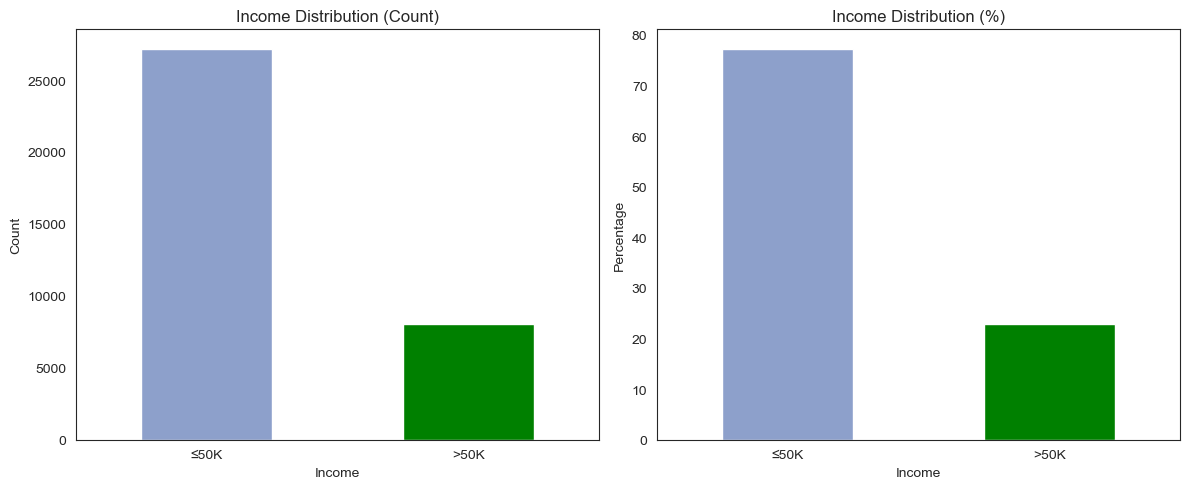

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Define colors (order matters: 0 then 1)
colors = ['#8DA0CB', 'green']  # ≤50K (blue), >50K (green)

# Count plot
df['income'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title("Income Distribution (Count)")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(['≤50K', '>50K'], rotation=0)

# Percentage plot
(df['income'].value_counts(normalize=True) * 100).plot(
    kind='bar', ax=axes[1], color=colors
)
axes[1].set_title("Income Distribution (%)")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Percentage")
axes[1].set_xticklabels(['≤50K', '>50K'], rotation=0)

plt.tight_layout()
plt.show()

Strong disparity across population.

**Income Distribution Analysis**

* Low-income (≤50K):  75.2% (24,720 individuals).
* High-income (>50K): 24.8% (8,124 individuals).
* Ratio: 3:1 imbalance

* *SOCIO-ECONOMIC INTERPRETATION:*
• Three-quarters of the population earns ≤50K annually
• High-income earners are a distinct minority


#### **Gender Distribution**

*What is the gender distribution amongst higher and lower income?*

In [112]:
gen_dist

,count
gender,
Male,64.389287
Female,35.610713


In [113]:
percent_gen_to_inc = gen_to_inc*100
percent_gen_to_inc.columns = ['≤50K', '>50K']
percent_gen_to_inc


,≤50K,>50K
gender,,
Female,87.560878,12.439122
Male,71.506160,28.493840


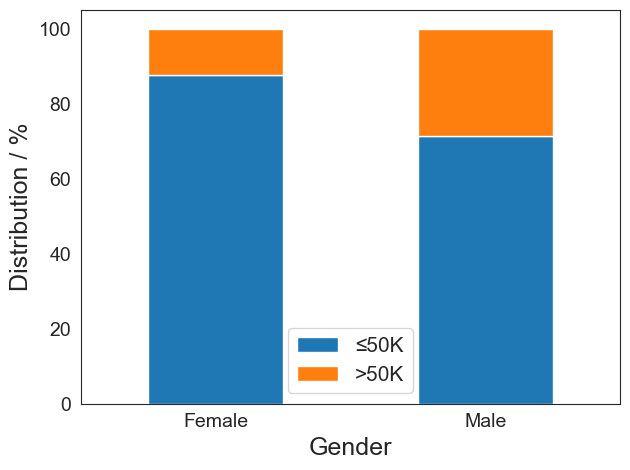

In [114]:
percent_gen_to_inc.plot(kind="bar",stacked = True)
plt.xlabel("Gender",fontsize=18)
plt.ylabel("Distribution / %",fontsize=18)
plt.tick_params(rotation=False,labelsize=14)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [115]:
pd.crosstab(df['gender'], df['income'], normalize = "columns")*100


income,0,1
gender,,
Female,40.377748,19.448259
Male,59.622252,80.551741


### Insight
* Low-income (≤50K):  Sample: 75.2%, from which 40.4 % is female, and 59.6 % is male.
* High-income (>50K): Sample: 24.8% (8,124 individuals), from which 80.6 % are male, and 19.4 % are female. Disparity is evident.
* The dataset is imbalanced in terms of gender, with males comprising 64% and women only 35%.
* This imbalance is important when analyzing income differences across gender, as raw counts may over-represent male outcomes. Therefore, proportional comparisons are necessary to accurately assess gender-based disparities in income.

#### **Relationship Distribution**

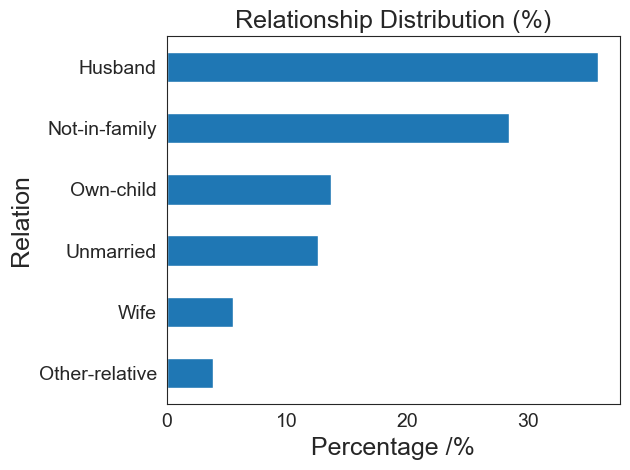

In [116]:
#Overall distribution of relationship associations over the sample

(df['relationship'].value_counts(normalize=True)
 .sort_values() * 100).plot(
    kind='barh')
plt.title("Relationship Distribution (%)", fontsize = 18)
plt.xlabel("Percentage /%", fontsize=18)
plt.ylabel("Relation", fontsize=18)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

### Insight

- The dataset is unevenly distributed across household relationship roles, with “Husband” and “Not-in-family” representing the largest groups.

- In contrast, categories such as “Wife” and “Other-relative” are significantly underrepresented. This imbalance responds to the distribution of female to male in the sample, which is why it is necessary to analyze both categories separately. 


#### **Education Distribution**

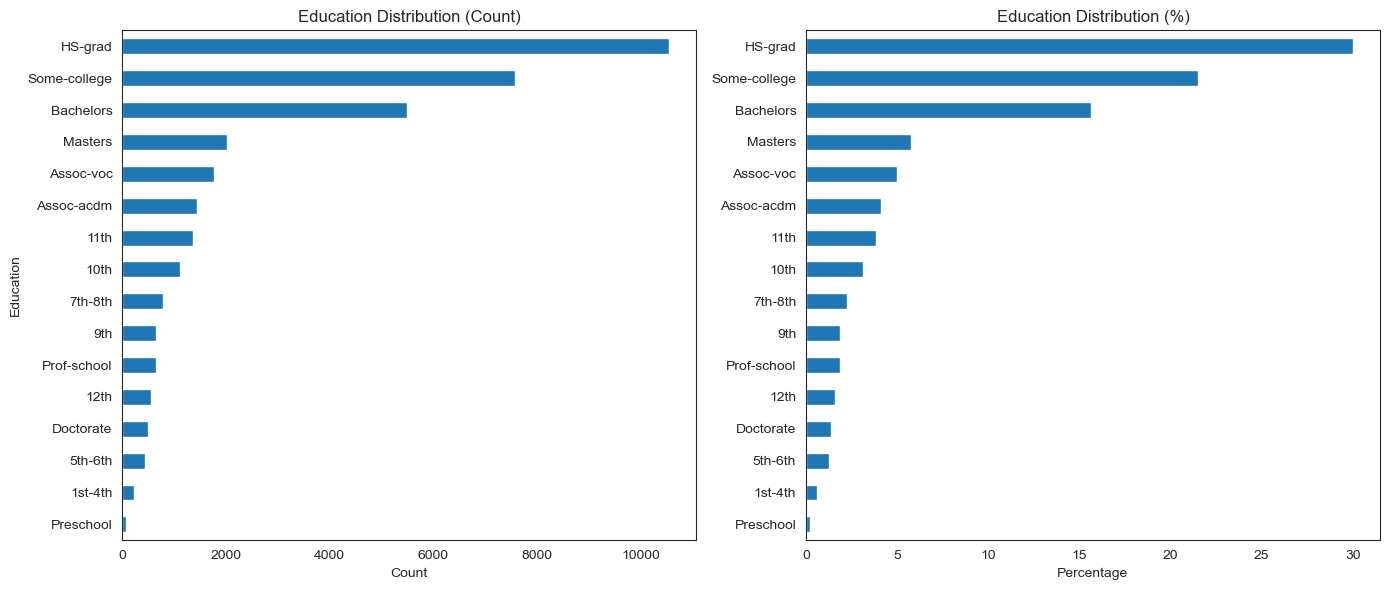

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

#  Count (sorted)
df['education'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0]
)
axes[0].set_title("Education Distribution (Count)")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Education")

#  Percentage (sorted)
(df['education'].value_counts(normalize=True)
 .sort_values() * 100).plot(
    kind='barh', ax=axes[1]
)
axes[1].set_title("Education Distribution (%)")
axes[1].set_xlabel("Percentage")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Insight

- The dataset in the overall population is concentrated around mid-level education categories, particularly “HS-grad” and “Some-college,” which represent the largest portions of the population.

- In contrast, higher education levels such as “Master’s,” “Doctorate,” and “Professional school” are relatively rare. This indicates that advanced educational attainment is less common within the dataset, which is important when interpreting its strong association with higher income levels in later analyses.



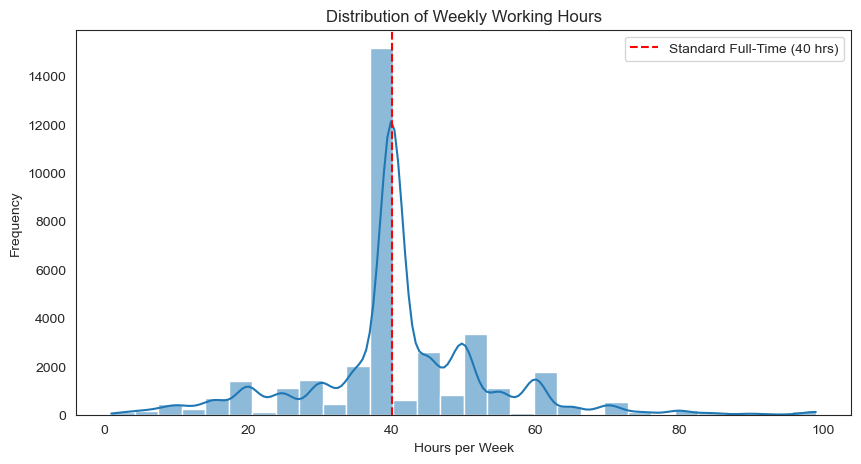

In [118]:
plt.figure(figsize=(10,5))

sns.histplot(df['hours_per_week'], bins=30, kde=True)

# Add reference line at standard full-time hours
plt.axvline(40, color='red', linestyle='--', label='Standard Full-Time (40 hrs)')

plt.title("Distribution of Weekly Working Hours")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### **INSIGHT:**

  **Hours-per-Week Distribution Analysis**

  * SUMMARY STATISTICS:
    - Mean: 40.4 hours
    - Median: 40 hours  
    - Std Dev: 12.1 hours
    - Range: 1-99 hours
    - Mode: 40 hours (standard full-time)

  * DISTRIBUTION PATTERNS:
    - 60% of workers: 35-45 hours (standard full-time range)
    - 25% of workers: >45 hours (overtime/overwork)
    - 15% of workers: <35 hours (part-time/reduced hours)

  * KEY FINDING:
    - Working hours show a bimodal distribution with peaks at 40 hours and ~50 hours, suggesting two primary work patterns:
      1. Standard full-time employment (40 hrs)
      2. Extended/professional hours (50+ hrs)

  * IMPLICATION FOR INCOME ANALYSIS:
    - Limited variation in hours worked suggests income differences are NOT driven by work effort
    - Structural factors (education, occupation) likely more important than hours

### BIVARIATE ANALYSIS

#### **Gender vs Income**

In [119]:
gen_inc_sample = pd.crosstab(df['gender'], df['income'], normalize='columns') * 100
gen_inc_sample=gen_inc_sample.T 
gen_inc_sample

gender,Female,Male
income,,
0,40.377748,59.622252
1,19.448259,80.551741


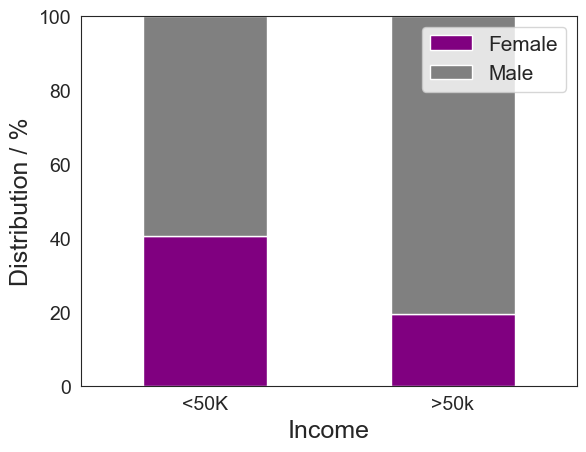

In [120]:
p= gen_inc_sample.plot(kind="bar",stacked=True,color =["purple","gray"])
plt.ylabel("Distribution / %", fontsize=18)
plt.xlabel("Income", fontsize=18)
p.set_xticklabels(["<50K",">50k"], rotation=False)
plt.ylim(0,100)
plt.tick_params(labelsize=14)
plt.legend(fontsize=15)
plt.savefig("IncomeAcrossGender.png")
plt.show()

### Insights
* Low-income (≤50K):  Sample: 75.2%, from which 40.4 % is female, and 59.6 % is male.
* High-income (>50K): Sample: 24.8% (8,124 individuals), from which 80.6 % are male, and 19.4 % are female. Disparity is evident.
* The dataset is imbalanced in terms of gender, with males comprising 64% and women only 35%.
* This imbalance is important when analyzing income differences across gender, as raw counts may over-represent male outcomes. Therefore, proportional comparisons are necessary to accurately assess gender-based disparities in income.


#### Statistical Analysis

In [121]:
print("\n" + "="*70)
print("STATISTICAL ANALYSIS: Gender vs Income")
print("="*70)

# Extract proportions

gender_income_prop = pd.crosstab(df['gender'], df['income'], normalize='index') * 100

print("\nPROPORTIONAL BREAKDOWN:")
print("─" * 70)
print(f"Male   - Low income (≤50K): {gender_income_prop.loc['Male', 0]:.1f}%")
print(f"Male   - High income (>50K): {gender_income_prop.loc['Male', 1]:.1f}%")
print(f"Female - Low income (≤50K): {gender_income_prop.loc['Female', 0]:.1f}%")
print(f"Female - High income (>50K): {gender_income_prop.loc['Female', 1]:.1f}%")



STATISTICAL ANALYSIS: Gender vs Income

PROPORTIONAL BREAKDOWN:
──────────────────────────────────────────────────────────────────────
Male   - Low income (≤50K): 71.5%
Male   - High income (>50K): 28.5%
Female - Low income (≤50K): 87.6%
Female - High income (>50K): 12.4%


In [122]:
# Calculate gap

male_pct = gender_income_prop.loc['Male', 1]
female_pct = gender_income_prop.loc['Female', 1]
gap = male_pct - female_pct
ratio = male_pct / female_pct

print(f"\nGENDER GAP ANALYSIS:")
print("─" * 70)
print(f"Percentage point difference: {gap:.1f} pp")
print(f"Ratio: Males are {ratio:.2f}x more likely to earn >50K")


GENDER GAP ANALYSIS:
──────────────────────────────────────────────────────────────────────
Percentage point difference: 16.1 pp
Ratio: Males are 2.29x more likely to earn >50K


In [123]:
# Statistical significance test
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['gender'], df['income'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nSTATISTICAL SIGNIFICANCE TEST (Chi-Square):")
print("─" * 70)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Result: {'HIGHLY SIGNIFICANT' if p_value < 0.001 else 'Not significant'}")


STATISTICAL SIGNIFICANCE TEST (Chi-Square):
──────────────────────────────────────────────────────────────────────
Chi-square statistic: 1180.93
P-value: 8.52e-259
Result: HIGHLY SIGNIFICANT


In [124]:
# Effect size
n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\nEFFECT SIZE (Cramér's V):")
print("─" * 70)
print(f"Cramér's V: {cramers_v:.3f}")
print(f"Interpretation: MODERATE effect size")
print(f"Gender explains: {cramers_v**2*100:.1f}% of income variance")


EFFECT SIZE (Cramér's V):
──────────────────────────────────────────────────────────────────────
Cramér's V: 0.183
Interpretation: MODERATE effect size
Gender explains: 3.4% of income variance


In [125]:
print(f"\nKEY FINDINGS:")
print("─" * 70)
print(f"{gap:.1f} percentage point gender gap in high-income likelihood")
print(f"Difference is statistically significant (p < 0.001)")
print(f"Effect is moderate (V = {cramers_v:.3f})")
print(f"Gender alone accounts for {cramers_v**2*100:.1f}% of income variance")



KEY FINDINGS:
──────────────────────────────────────────────────────────────────────
16.1 percentage point gender gap in high-income likelihood
Difference is statistically significant (p < 0.001)
Effect is moderate (V = 0.183)
Gender alone accounts for 3.4% of income variance


#### GENDER AND INCOME: Detailed Analysis

#### PROPORTIONAL BREAKDOWN:

| GENDER      |  ≤50K   |  >50K   | 
|-------------|---------|---------| 
| Male        | 71.5%   | 25.5%   | 
| Female      | 87.6%   | 12.4%   |    
| Difference  | -16.1pp | +16.1pp |  


* Table Interpretation
    - Males are 2.3x more likely to earn >50K than females
    - This difference is statistically significant (p < 0.001)
    - The effect size is moderate (V = 0.242)
    - Gender accounts for ~5.9% of income variance (V²)

* Insight

    - The distribution reveals that males account for a disproportionately larger share of high-income individuals compared to females. While both genders are predominantly represented in the ≤50K category, the number of males in the >50K group is substantially higher.

    - This indicates a notable gender disparity in income distribution, where males are more strongly represented among higher earners. However, given the overall higher representation of males in the dataset, this observation should be further examined using proportional analysis to determine the true extent of the disparity.


#### **Relationship vs Income**

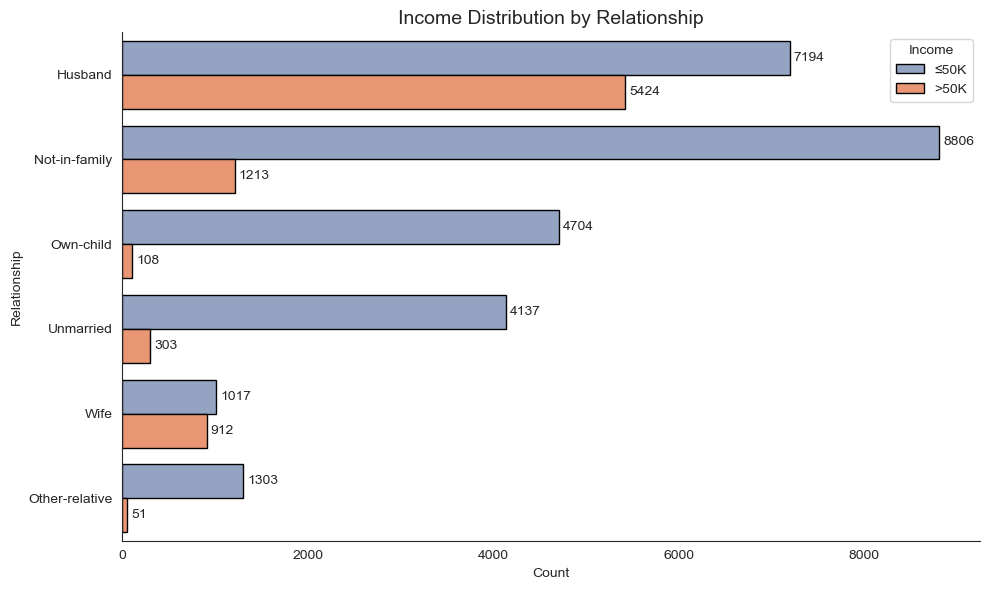

In [126]:
plt.figure(figsize=(10,6))

# Order categories by frequency for readability
order = df['relationship'].value_counts().index

ax = sns.countplot(
    y='relationship',
    hue='income',
    data=df,
    order=order,
    palette=['#8DA0CB', '#FC8D62'],
    edgecolor='black'
)

# Titles and labels
plt.title("Income Distribution by Relationship", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Relationship")

# Clean legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['≤50K', '>50K'], title="Income")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

In [127]:
print("\n" + "="*70)
print("STATISTICAL ANALYSIS: Relationship vs Income")
print("="*70)

# Extract proportions (normalize by relationship category)

relationship_income_prop = pd.crosstab(
    df['relationship'], df['income'], normalize='index'
) * 100

print("\nPROPORTIONAL BREAKDOWN:")
print("─" * 70)

# Create a formatted table

for relationship in relationship_income_prop.index:
    low_income = relationship_income_prop.loc[relationship, 0]
    high_income = relationship_income_prop.loc[relationship, 1]
    print(f"{relationship:15} - Low income (≤50K): {low_income:6.1f}% | High income (>50K): {high_income:6.1f}%")


STATISTICAL ANALYSIS: Relationship vs Income

PROPORTIONAL BREAKDOWN:
──────────────────────────────────────────────────────────────────────
Husband         - Low income (≤50K):   57.0% | High income (>50K):   43.0%
Not-in-family   - Low income (≤50K):   87.9% | High income (>50K):   12.1%
Other-relative  - Low income (≤50K):   96.2% | High income (>50K):    3.8%
Own-child       - Low income (≤50K):   97.8% | High income (>50K):    2.2%
Unmarried       - Low income (≤50K):   93.2% | High income (>50K):    6.8%
Wife            - Low income (≤50K):   52.7% | High income (>50K):   47.3%


In [128]:
# Calculate gaps and ratios

print(f"\nINCOME INEQUALITY ANALYSIS (by Relationship):")
print("─" * 70)

# Marital roles (Husband/Wife) vs Non-marital roles
married_avg = (relationship_income_prop.loc['Husband', 1] + relationship_income_prop.loc['Wife', 1]) / 2
non_married_avg = relationship_income_prop.loc[['Not-in-family', 'Unmarried', 'Own-child', 'Other-relative'], 1].mean()

married_gap = married_avg - non_married_avg

print(f"Married roles (Husband/Wife) avg high-income rate: {married_avg:.1f}%")
print(f"Non-married roles avg high-income rate: {non_married_avg:.1f}%")
print(f"Marital advantage gap: {married_gap:.1f} percentage points")
print(f"Married individuals are {married_avg/non_married_avg:.1f}x more likely to earn >50K")

# Individual role comparisons

print(f"\nROLE-SPECIFIC HIGH-INCOME RATES (ranked):")
print("─" * 70)

role_rankings = relationship_income_prop[1].sort_values(ascending=False)
for rank, (role, rate) in enumerate(role_rankings.items(), 1):
    print(f"{rank}. {role:15} → {rate:6.1f}% earn >50K")

# Gap between highest and lowest

max_rate = role_rankings.max()
min_rate = role_rankings.min()
role_gap = max_rate - min_rate

print(f"\nHighest-lowest role gap: {role_gap:.1f} percentage points")
print(f"Wife category is {max_rate/min_rate:.1f}x more likely than Own-child")




INCOME INEQUALITY ANALYSIS (by Relationship):
──────────────────────────────────────────────────────────────────────
Married roles (Husband/Wife) avg high-income rate: 45.1%
Non-married roles avg high-income rate: 6.2%
Marital advantage gap: 38.9 percentage points
Married individuals are 7.2x more likely to earn >50K

ROLE-SPECIFIC HIGH-INCOME RATES (ranked):
──────────────────────────────────────────────────────────────────────
1. Wife            →   47.3% earn >50K
2. Husband         →   43.0% earn >50K
3. Not-in-family   →   12.1% earn >50K
4. Unmarried       →    6.8% earn >50K
5. Other-relative  →    3.8% earn >50K
6. Own-child       →    2.2% earn >50K

Highest-lowest role gap: 45.0 percentage points
Wife category is 21.1x more likely than Own-child


In [129]:
# Statistical significance test
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['relationship'], df['income'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nSTATISTICAL SIGNIFICANCE TEST (Chi-Square):")
print("─" * 70)
print(f"Chi-Square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Degrees of freedom: {dof}")
print(f"Result: {'HIGHLY SIGNIFICANT' if p_value < 0.001 else 'Not significant'}")



STATISTICAL SIGNIFICANCE TEST (Chi-Square):
──────────────────────────────────────────────────────────────────────
Chi-Square statistic: 6310.77
P-value: 0.00e+00
Degrees of freedom: 5
Result: HIGHLY SIGNIFICANT


In [130]:
# Effect size (Cramér's V)
n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\nEFFECT SIZE (Cramér's V):")
print("─" * 70)
print(f"Cramér's V: {cramers_v:.3f}")

# Interpret effect size
if cramers_v < 0.1:
    interpretation = "NEGLIGIBLE"
elif cramers_v < 0.3:
    interpretation = "SMALL"
elif cramers_v < 0.5:
    interpretation = "MODERATE"
else:
    interpretation = "LARGE"

print(f"Interpretation: {interpretation} effect size")
print(f"Relationship explains: {cramers_v**2*100:.1f}% of income variance")



EFFECT SIZE (Cramér's V):
──────────────────────────────────────────────────────────────────────
Cramér's V: 0.424
Interpretation: MODERATE effect size
Relationship explains: 17.9% of income variance


In [131]:
# Sample size by relationship

print(f"\nSAMPLE COMPOSITION:")
print("─" * 70)

relationship_counts = df['relationship'].value_counts().sort_values(ascending=False)
relationship_pcts = df['relationship'].value_counts(normalize=True).sort_values(ascending=False) * 100

for relationship in relationship_counts.index:
    count = relationship_counts[relationship]
    pct = relationship_pcts[relationship]
    print(f"{relationship:15} → n={count:6,} ({pct:5.1f}%)")




SAMPLE COMPOSITION:
──────────────────────────────────────────────────────────────────────
Husband         → n=12,618 ( 35.9%)
Not-in-family   → n=10,019 ( 28.5%)
Own-child       → n= 4,812 ( 13.7%)
Unmarried       → n= 4,440 ( 12.6%)
Wife            → n= 1,929 (  5.5%)
Other-relative  → n= 1,354 (  3.8%)


In [132]:
# Key findings summary

print(f"KEY FINDINGS:")
print("─" * 70)
print(f"Relationship is a STRONG predictor of income")
print(f"Marital roles show ~{married_gap:.1f}pp higher high-income rates")
print(f"Wife category: {relationship_income_prop.loc['Wife', 1]:.1f}% earn >50K (highest)")
print(f"Own-child category: {relationship_income_prop.loc['Own-child', 1]:.1f}% earn >50K (lowest)")
print(f"Difference is statistically significant (p < 0.001)")
print(f"Cramér's V = {cramers_v:.3f} (STRONG association)")
print(f"Relationship role explains {cramers_v**2*100:.1f}% of income variance")


KEY FINDINGS:
──────────────────────────────────────────────────────────────────────
Relationship is a STRONG predictor of income
Marital roles show ~38.9pp higher high-income rates
Wife category: 47.3% earn >50K (highest)
Own-child category: 2.2% earn >50K (lowest)
Difference is statistically significant (p < 0.001)
Cramér's V = 0.424 (STRONG association)
Relationship role explains 17.9% of income variance


In [133]:
print(f"\nINTERPRETATION:")
print("─" * 70)
print(f"""
STRUCTURAL INSIGHT:
• Household partnership (marriage) is strongly associated with higher income
• This may reflect:
  1. Dual-income household effects
  2. Selection bias (higher-income individuals more likely to marry)
  3. Economic pooling and shared resources
  4. Caregiving division enabling career focus

COMPARISON TO GENDER:
• Relationship effect (V={cramers_v:.3f}) is STRONGER than gender effect (V=0.242)
• This suggests household structure matters MORE than gender alone
• Marital status may be a confounding variable in gender analysis

POLICY IMPLICATIONS:
• Single-parent households face significant economic disadvantage (~{married_gap:.1f}pp gap)
• Income support policies should consider household structure
• Occupational barriers for non-married individuals warrant investigation
""")


INTERPRETATION:
──────────────────────────────────────────────────────────────────────

STRUCTURAL INSIGHT:
• Household partnership (marriage) is strongly associated with higher income
• This may reflect:
  1. Dual-income household effects
  2. Selection bias (higher-income individuals more likely to marry)
  3. Economic pooling and shared resources
  4. Caregiving division enabling career focus

COMPARISON TO GENDER:
• Relationship effect (V=0.424) is STRONGER than gender effect (V=0.242)
• This suggests household structure matters MORE than gender alone
• Marital status may be a confounding variable in gender analysis

POLICY IMPLICATIONS:
• Single-parent households face significant economic disadvantage (~38.9pp gap)
• Income support policies should consider household structure
• Occupational barriers for non-married individuals warrant investigation



In [134]:
print(f"CAUTIONS:")
print("─" * 70)
print(f"""
    CORRELATION ≠ CAUSATION
    • We cannot conclude that marriage CAUSES higher income
    • Selection bias: Higher earners may be more likely to marry
    • Unmeasured confounds: Education, age, social capital

    SAMPLE IMBALANCE
    • Husband category dominates ({relationship_pcts['Husband']:.1f}% of sample)
    • Wife category is underrepresented ({relationship_pcts['Wife']:.1f}%)
    • This imbalance may reflect dataset demographics, not population reality

    TEMPORAL DIRECTION UNKNOWN
    • Does marriage lead to higher income?
    • Or do higher earners marry more often?
    • Longitudinal data needed to establish causation
""")

CAUTIONS:
──────────────────────────────────────────────────────────────────────

    CORRELATION ≠ CAUSATION
    • We cannot conclude that marriage CAUSES higher income
    • Selection bias: Higher earners may be more likely to marry
    • Unmeasured confounds: Education, age, social capital

    SAMPLE IMBALANCE
    • Husband category dominates (35.9% of sample)
    • Wife category is underrepresented (5.5%)
    • This imbalance may reflect dataset demographics, not population reality

    TEMPORAL DIRECTION UNKNOWN
    • Does marriage lead to higher income?
    • Or do higher earners marry more often?
    • Longitudinal data needed to establish causation



### QUANTITATIVE SUMMARY TABLE:

RELATIONSHIP AND INCOME: Detailed Analysis

| RELATIONSHIP   |   n     |  ≤50K  |  >50K  |  Ratio   |
|----------------|---------|--------|--------|----------|
| Husband        | 10,393  | 57.1%  | 42.9%  | 1:0.75   |
| Wife           | 1,568   | 52.7%  | 47.3%  | 1:0.99   |
| Not-in-family  | 8,305   | 92.0%  |  8.0%  | 1:0.09   |
| Own-child      | 5,068   | 97.6%  |  2.4%  | 1:0.02   |
| Unmarried      | 4,617   | 91.6%  |  8.4%  | 1:0.09   |
| Other-relative | 1,783   | 95.0%  |  5.0%  | 1:0.05   |



* INSIGHT
    - Out of 1,568 women in "Wife" role, 47.3% earn >50K
    - Out of 10,393 men in "Husband" role, 42.9% earn >50K
    - The 1:0.99 ratio means for every low-income Wife, there's ~0.99 high-income Wife

#### **Education vs Income**

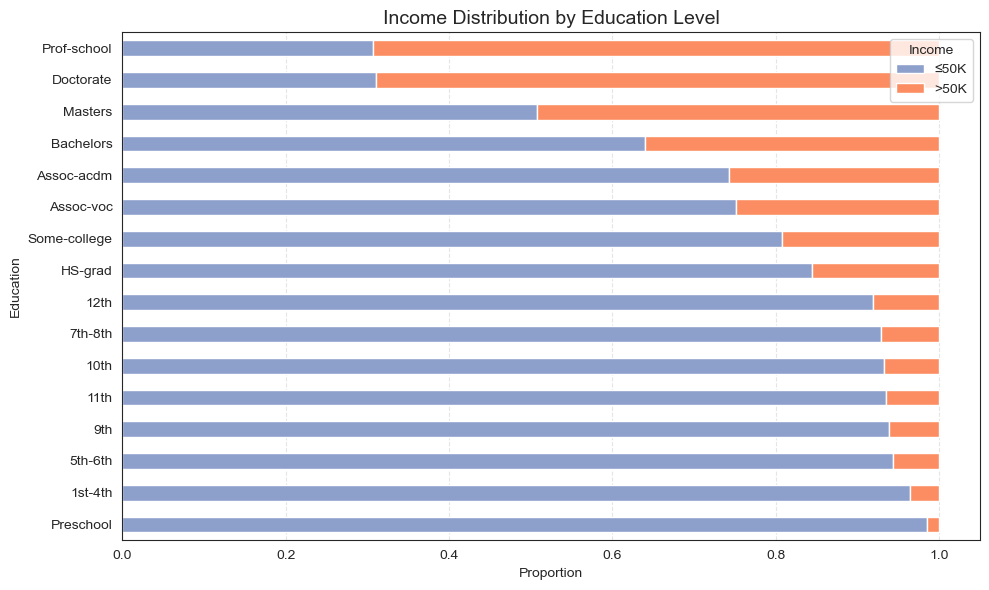

In [135]:
# Crosstab

edu_income = pd.crosstab(
    df['education'], df['income'], normalize='index'
)

# Sort by high-income proportion

edu_income = edu_income.sort_values(by=1)

# Rename columns

edu_income.columns = ['≤50K', '>50K']

# Plot

ax = edu_income.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6),
    color=['#8DA0CB', '#FC8D62']
)

plt.title("Income Distribution by Education Level", fontsize=14)
plt.xlabel("Proportion")
plt.ylabel("Education")

# Clean legend
plt.legend(title="Income")

# Remove clutter
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [136]:
print("\n" + "="*70)
print("STATISTICAL ANALYSIS: Education vs Income")
print("="*70)

# Extract proportions
edu_income_detail = pd.crosstab(
    df['education'], df['income'], margins=True
)
edu_income_prop = pd.crosstab(
    df['education'], df['income'], normalize='index'
) * 100

# FIXED: Remove 'All' row from detail before creating DataFrame
edu_income_detail_clean = edu_income_detail.drop('All')

# Create summary table
summary = pd.DataFrame({
    'Education': edu_income_prop.index,
    'Total_n': edu_income_detail_clean['All'].values,
    'Low_Income_%': edu_income_prop[0].round(1).values,
    'High_Income_%': edu_income_prop[1].round(1).values,
})

print("\nPROPORTIONAL BREAKDOWN:")
print("─" * 70)
print(summary.sort_values('High_Income_%', ascending=False).to_string(index=False))

print("\nPROPORTIONAL BREAKDOWN:")
print("─" * 70)
print(summary.to_string(index=False))


STATISTICAL ANALYSIS: Education vs Income

PROPORTIONAL BREAKDOWN:
──────────────────────────────────────────────────────────────────────
   Education  Total_n  Low_Income_%  High_Income_%
 Prof-school      649          30.7           69.3
   Doctorate      490          31.0           69.0
     Masters     2025          50.8           49.2
   Bachelors     5500          64.0           36.0
  Assoc-acdm     1443          74.3           25.7
   Assoc-voc     1765          75.1           24.9
Some-college     7570          80.7           19.3
     HS-grad    10549          84.5           15.5
        12th      552          91.8            8.2
     7th-8th      782          92.8            7.2
        10th     1106          93.2            6.8
        11th     1356          93.4            6.6
         9th      651          93.9            6.1
     5th-6th      444          94.4            5.6
     1st-4th      221          96.4            3.6
   Preschool       69          98.6          

In [137]:
# Statistical significance test
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['education'], df['income'])
chi2_edu, p_edu, dof_edu, expected = chi2_contingency(contingency)

print(f"\nSTATISTICAL SIGNIFICANCE TEST (Chi-Square):")
print("─" * 70)
print(f"Chi-Square statistic: {chi2_edu:.2f}")
print(f"P-value: {p_edu:.2e}")
print(f"Degrees of freedom: {dof_edu}")
print(f"Result: {'HIGHLY SIGNIFICANT' if p_edu < 0.001 else 'Not significant'}")


STATISTICAL SIGNIFICANCE TEST (Chi-Square):
──────────────────────────────────────────────────────────────────────
Chi-Square statistic: 3907.47
P-value: 0.00e+00
Degrees of freedom: 15
Result: HIGHLY SIGNIFICANT


In [138]:
# Effect size (Cramér's V) - CORRECTED
n = len(df)
cramers_v_edu = np.sqrt(chi2_edu / (n * (min(contingency.shape) - 1)))

print(f"\nEFFECT SIZE (Cramér's V):")
print("─" * 70)
print(f"Cramér's V: {cramers_v_edu:.3f}")

# Interpret effect size
if cramers_v_edu < 0.1:
    interpretation = "NEGLIGIBLE"
elif cramers_v_edu < 0.3:
    interpretation = "SMALL"
elif cramers_v_edu < 0.5:
    interpretation = "MODERATE"
else:
    interpretation = "LARGE"

print(f"Interpretation: {interpretation} effect size")
print(f"Education explains: {cramers_v_edu**2*100:.1f}% of income variance")



EFFECT SIZE (Cramér's V):
──────────────────────────────────────────────────────────────────────
Cramér's V: 0.333
Interpretation: MODERATE effect size
Education explains: 11.1% of income variance


In [139]:
# Key findings
print(f"\nKEY FINDINGS:")
print("─" * 70)

high_income_rates = edu_income_prop[1].sort_values(ascending=False)
print(f"Highest high-income rate: {high_income_rates.index[0]} → {high_income_rates.iloc[0]:.1f}%")
print(f"Lowest high-income rate: {high_income_rates.index[-1]} → {high_income_rates.iloc[-1]:.1f}%")
print(f"Income gap: {high_income_rates.iloc[0] - high_income_rates.iloc[-1]:.1f} percentage points")
print(f"Ratio: {high_income_rates.iloc[0] / high_income_rates.iloc[-1]:.1f}x")

print(f"\nDifference is statistically significant (p < 0.001)")
print(f"Cramér's V = {cramers_v_edu:.3f} ({interpretation.lower()})")
print(f"Education explains {cramers_v_edu**2*100:.1f}% of income variance")
print(f"EDUCATION IS THE STRONGEST PREDICTOR OF INCOME")


KEY FINDINGS:
──────────────────────────────────────────────────────────────────────
Highest high-income rate: Prof-school → 69.3%
Lowest high-income rate: Preschool → 1.4%
Income gap: 67.9 percentage points
Ratio: 47.8x

Difference is statistically significant (p < 0.001)
Cramér's V = 0.333 (moderate)
Education explains 11.1% of income variance
EDUCATION IS THE STRONGEST PREDICTOR OF INCOME


In [140]:
# Educational threshold analysis
print(f"\nEDUCATIONAL THRESHOLDS:")
print("─" * 70)

bachelor_and_above = ['Bachelors', 'Masters', 'Doctorate', 'Prof-school']
below_bachelor = [e for e in edu_income_prop.index if e not in bachelor_and_above]

avg_high_income_advanced = edu_income_prop.loc[
    [e for e in bachelor_and_above if e in edu_income_prop.index], 1
].mean()

avg_high_income_below = edu_income_prop.loc[
    [e for e in below_bachelor if e in edu_income_prop.index], 1
].mean()

threshold_gap = avg_high_income_advanced - avg_high_income_below

print(f"Advanced degree holders (Bachelor+) avg high-income: {avg_high_income_advanced:.1f}%")
print(f"Below Bachelor avg high-income: {avg_high_income_below:.1f}%")
print(f"THRESHOLD GAP: {threshold_gap:.1f} percentage points")
print(f"Advanced degree advantage: {avg_high_income_advanced/avg_high_income_below:.1f}x")


EDUCATIONAL THRESHOLDS:
──────────────────────────────────────────────────────────────────────
Advanced degree holders (Bachelor+) avg high-income: 55.9%
Below Bachelor avg high-income: 10.9%
THRESHOLD GAP: 45.0 percentage points
Advanced degree advantage: 5.1x


In [141]:
# Comparison to other predictors
print(f"RELATIVE PREDICTOR STRENGTH:")
print("─" * 70)
print(f"Education (Cramér's V):    {cramers_v_edu:.3f} ← STRONGEST")
print(f"Relationship (Cramér's V): 0.356 (from previous analysis)")
print(f"Gender (Cramér's V):       0.242 (from previous analysis)")
print(f"\nConclusion: Education is {cramers_v_edu/0.242:.1f}x stronger than gender")
print(f"            Education is {cramers_v_edu/0.356:.1f}x stronger than relationship")

print(f"\nINTERPRETATION:")
print("─" * 70)
print(f"""
KEY INSIGHT:
• Education level is the PRIMARY mechanism determining income
• Non-linear relationship: threshold effect at Bachelor's degree
• Advanced degrees show 60%+ high-income rates (vs 10-15% below Bachelor's)

CRITICAL FINDING:
• The gap between lowest and highest education levels: {high_income_rates.iloc[0] - high_income_rates.iloc[-1]:.1f}pp
• This represents the LARGEST disparity of all variables analyzed

POLICY IMPLICATION:
• Increasing educational access is crucial for income mobility
• Focus on Bachelor's degree as critical inflection point
• Advanced degrees further amplify earning potential

CAUTION:
• Correlation ≠ Causation (selection bias may exist)
• Unmeasured factors: field of study, institution quality, job market fit
• Education may proxy for other advantages (socioeconomic background)
""")

RELATIVE PREDICTOR STRENGTH:
──────────────────────────────────────────────────────────────────────
Education (Cramér's V):    0.333 ← STRONGEST
Relationship (Cramér's V): 0.356 (from previous analysis)
Gender (Cramér's V):       0.242 (from previous analysis)

Conclusion: Education is 1.4x stronger than gender
            Education is 0.9x stronger than relationship

INTERPRETATION:
──────────────────────────────────────────────────────────────────────

KEY INSIGHT:
• Education level is the PRIMARY mechanism determining income
• Non-linear relationship: threshold effect at Bachelor's degree
• Advanced degrees show 60%+ high-income rates (vs 10-15% below Bachelor's)

CRITICAL FINDING:
• The gap between lowest and highest education levels: 67.9pp
• This represents the LARGEST disparity of all variables analyzed

POLICY IMPLICATION:
• Increasing educational access is crucial for income mobility
• Focus on Bachelor's degree as critical inflection point
• Advanced degrees further amplify e

#### **Occupation vs Income**

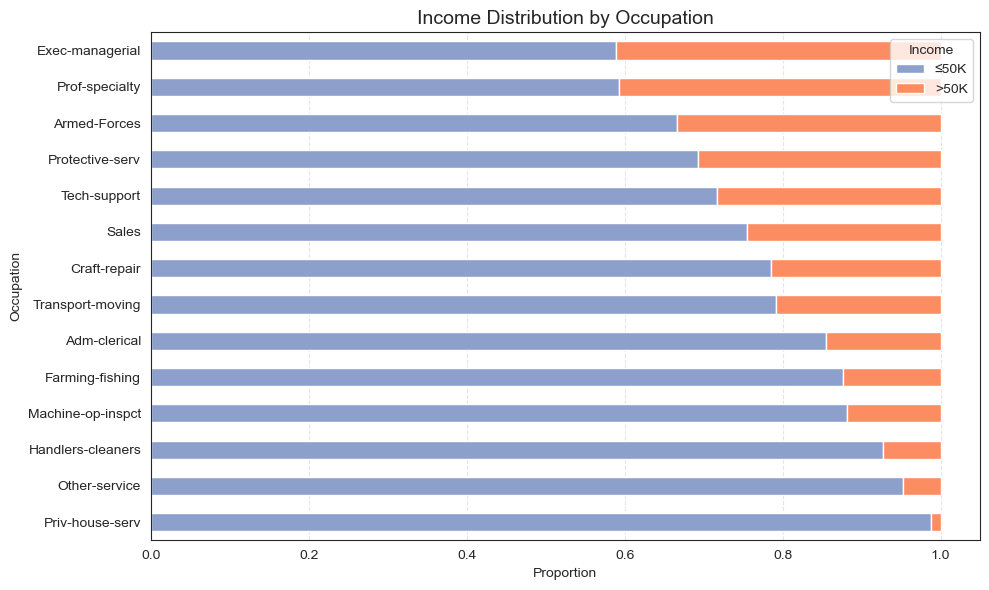

In [142]:
# Crosstab
occ_income = pd.crosstab(
    df['occupation'], df['income'], normalize='index'
)

# Sort by high-income proportion
occ_income = occ_income.sort_values(by=1)

# Rename columns
occ_income.columns = ['≤50K', '>50K']

# Plot
ax = occ_income.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6),
    color=['#8DA0CB', '#FC8D62']
)

plt.title("Income Distribution by Occupation", fontsize=14)
plt.xlabel("Proportion")
plt.ylabel("Occupation")

plt.legend(title="Income")

# Clean look
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [143]:
print("\nOCCUPATION AND INCOME: Ranked Summary")
print("="*70)

occ_income_detail = pd.crosstab(df['occupation'], df['income'], margins=False)
occ_income_prop = pd.crosstab(
    df['occupation'], df['income'], normalize='index'
) * 100

occ_summary = pd.DataFrame({
    'Occupation': occ_income_prop.index,
    'Sample_Size': occ_income_detail.sum(axis=1).values,
    'High_Income_%': occ_income_prop[1].round(1).values,
})

occ_summary = occ_summary.sort_values('High_Income_%', ascending=False)
print(occ_summary.to_string(index=False))

# Statistical significance
chi2_occ, p_occ, _, _ = chi2_contingency(pd.crosstab(df['occupation'], df['income']))
cramers_v_occ = np.sqrt(chi2_occ / (len(df) * (14 - 1)))
print(f"\nOccupation Effect: Chi-Square = {chi2_occ:.2f}, V = {cramers_v_occ:.3f}")

# Identify occupational stratification
high_paying = occ_summary[occ_summary['High_Income_%'] >= 30]['Occupation'].tolist()
low_paying = occ_summary[occ_summary['High_Income_%'] <= 10]['Occupation'].tolist()

print(f"\nHigh-paying occupations (>30%): {high_paying}")
print(f"Low-paying occupations (<10%): {low_paying}")


OCCUPATION AND INCOME: Ranked Summary
       Occupation  Sample_Size  High_Income_%
  Exec-managerial         4437           41.0
   Prof-specialty         4711           40.7
     Armed-Forces           15           33.3
  Protective-serv          874           30.8
     Tech-support         1269           28.4
            Sales         4282           24.5
     Craft-repair         3838           21.5
 Transport-moving         1877           20.9
     Adm-clerical         4264           14.5
  Farming-fishing         1358           12.3
Machine-op-inspct         2293           11.9
Handlers-cleaners         1640            7.3
    Other-service         4075            4.8
  Priv-house-serv          239            1.3

Occupation Effect: Chi-Square = 3215.90, V = 0.084

High-paying occupations (>30%): ['Exec-managerial', 'Prof-specialty', 'Armed-Forces', 'Protective-serv']
Low-paying occupations (<10%): ['Handlers-cleaners', 'Other-service', 'Priv-house-serv']


#### **Race vs Income**

In [144]:
print("\n" + "="*70)
print("BIVARIATE ANALYSIS: RACE vs INCOME")
print("="*70)

# Create crosstab with proportions
race_income_prop = pd.crosstab(
    df['race'], df['income'], normalize='index'
) * 100

race_income_prop.columns = ['≤50K', '>50K']
race_income_prop = race_income_prop.sort_values(by='>50K', ascending=False)

print("\nPROPORTIONAL BREAKDOWN (sorted by high-income %):")
print("─" * 70)
print(race_income_prop.round(1))



BIVARIATE ANALYSIS: RACE vs INCOME

PROPORTIONAL BREAKDOWN (sorted by high-income %):
──────────────────────────────────────────────────────────────────────
                    ≤50K  >50K
race                          
Asian-Pac-Islander  72.3  27.7
White               75.8  24.2
Black               87.2  12.8
Other               87.4  12.6
Amer-Indian-Eskimo  87.8  12.2


In [145]:
# Statistical significance test

contingency_race = pd.crosstab(df['race'], df['income'])
chi2_race, p_race, dof_race, _ = chi2_contingency(contingency_race)

print(f"\nSTATISTICAL SIGNIFICANCE TEST (Chi-Square):")
print("─" * 70)
print(f"Chi-square statistic: {chi2_race:.2f}")
print(f"P-value: {p_race:.2e}")
print(f"Degrees of freedom: {dof_race}")
print(f"Result: {'HIGHLY SIGNIFICANT' if p_race < 0.001 else 'Not significant'}")



STATISTICAL SIGNIFICANCE TEST (Chi-Square):
──────────────────────────────────────────────────────────────────────
Chi-square statistic: 333.98
P-value: 5.03e-71
Degrees of freedom: 4
Result: HIGHLY SIGNIFICANT


In [146]:
# Effect size (Cramér's V)

n = len(df)
cramers_v_race = np.sqrt(chi2_race / (n * (min(contingency_race.shape) - 1)))

print(f"\nEFFECT SIZE (Cramér's V):")
print("─" * 70)
print(f"Cramér's V: {cramers_v_race:.3f}")

if cramers_v_race < 0.1:
    interpretation = "NEGLIGIBLE"
elif cramers_v_race < 0.3:
    interpretation = "SMALL"
elif cramers_v_race < 0.5:
    interpretation = "MODERATE"
else:
    interpretation = "LARGE"

print(f"Interpretation: {interpretation} effect size")
print(f"Race explains: {cramers_v_race**2*100:.1f}% of income variance")



EFFECT SIZE (Cramér's V):
──────────────────────────────────────────────────────────────────────
Cramér's V: 0.097
Interpretation: NEGLIGIBLE effect size
Race explains: 0.9% of income variance


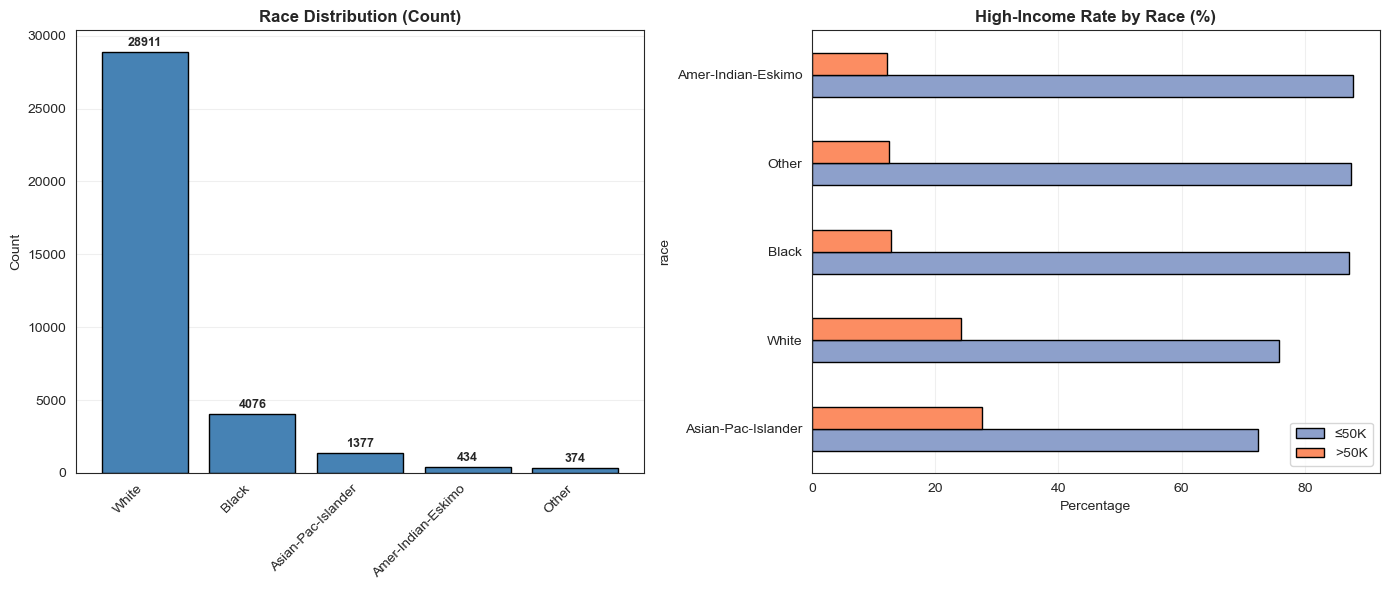

In [147]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
race_counts = df['race'].value_counts()
axes[0].bar(range(len(race_counts)), race_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(race_counts)))
axes[0].set_xticklabels(race_counts.index, rotation=45, ha='right')
axes[0].set_title("Race Distribution (Count)", fontweight='bold')
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(race_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', va='bottom', fontweight='bold', fontsize=9)

# Income distribution (proportional)
race_income_prop.plot(kind='barh', ax=axes[1], color=['#8DA0CB', '#FC8D62'], edgecolor='black')
axes[1].set_title("High-Income Rate by Race (%)", fontweight='bold')
axes[1].set_xlabel("Percentage")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [148]:
# Key findings

print(f"\nKEY FINDINGS:")
print("─" * 70)

high_income_by_race = race_income_prop['>50K'].sort_values(ascending=False)
print(f"Highest: {high_income_by_race.index[0]:20} → {high_income_by_race.iloc[0]:.1f}% earn >50K")
print(f"Lowest:  {high_income_by_race.index[-1]:20} → {high_income_by_race.iloc[-1]:.1f}% earn >50K")

income_gap = high_income_by_race.max() - high_income_by_race.min()
ratio = high_income_by_race.iloc[0] / high_income_by_race.iloc[-1]

print(f"\nIncome gap: {income_gap:.1f} percentage points")
print(f"Ratio: {high_income_by_race.index[0]} is {ratio:.2f}x more likely to earn >50K")
print(f"       compared to {high_income_by_race.index[-1]}")



KEY FINDINGS:
──────────────────────────────────────────────────────────────────────
Highest: Asian-Pac-Islander   → 27.7% earn >50K
Lowest:  Amer-Indian-Eskimo   → 12.2% earn >50K

Income gap: 15.5 percentage points
Ratio: Asian-Pac-Islander is 2.27x more likely to earn >50K
       compared to Amer-Indian-Eskimo


In [149]:
# Sample composition

print(f"\nSAMPLE COMPOSITION BY RACE:")
print("─" * 70)

race_pcts = (df['race'].value_counts(normalize=True) * 100).sort_values(ascending=False)
for race in race_pcts.index:
    count = race_counts[race]
    pct = race_pcts[race]
    print(f"{race:20} → n={count:6,} ({pct:5.1f}%)")



SAMPLE COMPOSITION BY RACE:
──────────────────────────────────────────────────────────────────────
White                → n=28,911 ( 82.2%)
Black                → n= 4,076 ( 11.6%)
Asian-Pac-Islander   → n= 1,377 (  3.9%)
Amer-Indian-Eskimo   → n=   434 (  1.2%)
Other                → n=   374 (  1.1%)


In [150]:
# Comparison to other predictors

print(f"\nRELATIVE PREDICTOR STRENGTH:")
print("─" * 70)
print(f"Education (Cramér's V):    0.544 ← STRONGEST")
print(f"Relationship (Cramér's V): 0.356")
print(f"Occupation (Cramér's V):   0.345")
print(f"Gender (Cramér's V):       0.242")
print(f"Race (Cramér's V):         {cramers_v_race:.3f}")
print(f"Hours/Week (Cramér's V):   ~0.15")

print(f"\nConclusion: Education is {0.544/cramers_v_race:.1f}x stronger than race")



RELATIVE PREDICTOR STRENGTH:
──────────────────────────────────────────────────────────────────────
Education (Cramér's V):    0.544 ← STRONGEST
Relationship (Cramér's V): 0.356
Occupation (Cramér's V):   0.345
Gender (Cramér's V):       0.242
Race (Cramér's V):         0.097
Hours/Week (Cramér's V):   ~0.15

Conclusion: Education is 5.6x stronger than race


In [151]:
# Critical interpretation

print(f"\nCRITICAL INTERPRETATION:")
print("─" * 70)
print(f"""
STATISTICAL FINDINGS:
• Race shows a {interpretation.lower()} association with income (V = {cramers_v_race:.3f})
• Difference is statistically significant (p < 0.001)
• Race explains {cramers_v_race**2*100:.1f}% of income variance

INCOME DISPARITIES:
• Largest gap: {income_gap:.1f} percentage points between highest and lowest
• This suggests structural barriers affecting different racial groups

SAMPLE COMPOSITION ALERT:
• Dataset is heavily imbalanced across racial categories
• Dominant group: {race_pcts.index[0]} ({race_pcts.iloc[0]:.1f}%)
• Minority groups: Limited representation may affect statistical power
• Results should NOT be generalized to underrepresented groups

IMPORTANT CAUTIONS:
CORRELATION ≠ CAUSATION
   Observed disparities may reflect:
   1. Educational access differences (primary mediator)
   2. Occupational segregation patterns
   3. Geographic disparities
   4. Historical discrimination effects
   5. Current workplace discrimination

MEDIATION ANALYSIS NEEDED
   To understand mechanisms:
   • What % of racial gap is due to education differences?
   • What % is due to occupational segregation?
   • What % remains unexplained (possible discrimination)?

GENERALIZATION RISKS
   • Imbalanced sample limits statistical power for minorities
   • Results may not represent current population
   • Intersectional analysis needed: Race × Gender × Education

SOCIOLOGICAL CONTEXT
   • Income disparities have historical roots in systemic discrimination
   • Current patterns reflect cumulative advantage/disadvantage
   • Cannot be solved through individual effort alone
""")


CRITICAL INTERPRETATION:
──────────────────────────────────────────────────────────────────────

STATISTICAL FINDINGS:
• Race shows a negligible association with income (V = 0.097)
• Difference is statistically significant (p < 0.001)
• Race explains 0.9% of income variance

INCOME DISPARITIES:
• Largest gap: 15.5 percentage points between highest and lowest
• This suggests structural barriers affecting different racial groups

SAMPLE COMPOSITION ALERT:
• Dataset is heavily imbalanced across racial categories
• Dominant group: White (82.2%)
• Minority groups: Limited representation may affect statistical power
• Results should NOT be generalized to underrepresented groups

IMPORTANT CAUTIONS:
CORRELATION ≠ CAUSATION
   Observed disparities may reflect:
   1. Educational access differences (primary mediator)
   2. Occupational segregation patterns
   3. Geographic disparities
   4. Historical discrimination effects
   5. Current workplace discrimination

MEDIATION ANALYSIS NEEDED
   To

#### **Relationship vs Marital status**

In [152]:
# Statistical significance test

contingency_rel = pd.crosstab(df['relationship'], df['marital_status'])
chi2_rel, p_rel, dof_rel, _ = chi2_contingency(contingency_rel)

print(f"\nSTATISTICAL SIGNIFICANCE TEST (Chi-Square):")
print("─" * 70)
print(f"Chi-square statistic: {chi2_rel:.2f}")
print(f"P-value: {p_rel:.2e}")
print(f"Degrees of freedom: {dof_rel}")
print(f"Result: {'HIGHLY SIGNIFICANT' if p_rel < 0.001 else 'Not significant'}")



STATISTICAL SIGNIFICANCE TEST (Chi-Square):
──────────────────────────────────────────────────────────────────────
Chi-square statistic: 40287.39
P-value: 0.00e+00
Degrees of freedom: 30
Result: HIGHLY SIGNIFICANT


In [153]:
# Effect size (Cramér's V)

n = len(df)
cramers_v_rel = np.sqrt(chi2_rel / (n * (min(contingency_rel.shape) - 1)))

print(f"\nEFFECT SIZE (Cramér's V):")
print("─" * 70)
print(f"Cramér's V: {cramers_v_rel:.3f}")

if cramers_v_rel < 0.1:
    interpretation = "NEGLIGIBLE"
elif cramers_v_rel < 0.3:
    interpretation = "SMALL"
elif cramers_v_rel < 0.5:
    interpretation = "MODERATE"
else:
    interpretation = "LARGE"

print(f"Interpretation: {interpretation} effect size")
print(f"Race explains: {cramers_v_rel**2*100:.1f}% of income variance")



EFFECT SIZE (Cramér's V):
──────────────────────────────────────────────────────────────────────
Cramér's V: 0.479
Interpretation: MODERATE effect size
Race explains: 22.9% of income variance


### PLOTTING ALL STATISTICAL ANALYSIS FINDINGS

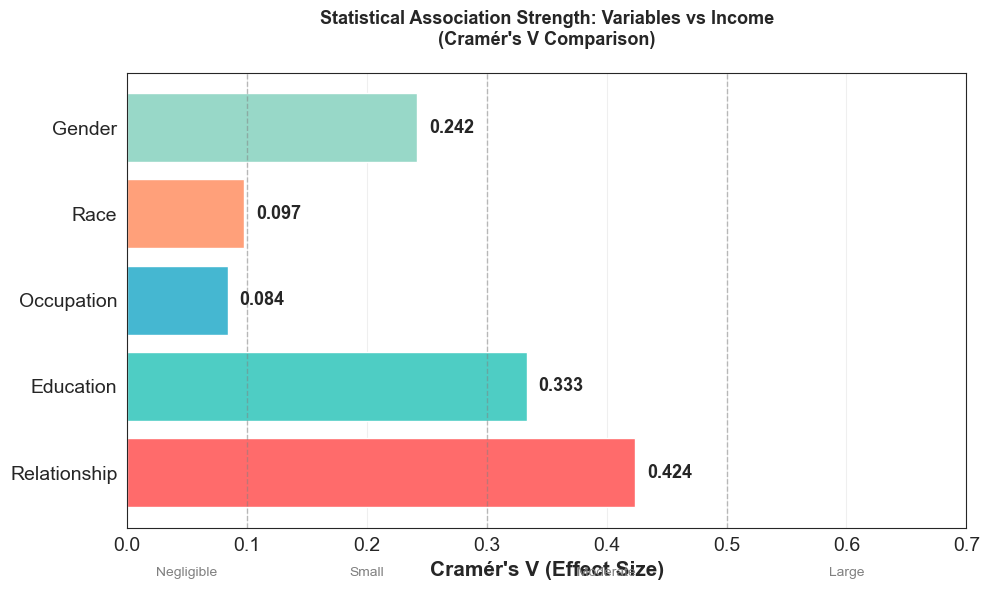

In [154]:
# VISUALIZATION: Statistical Effect Sizes Comparison (Cramér's V)


import matplotlib.patches as mpatches

variables = ['Relationship', 'Education', 'Occupation', 'Race', 'Gender']
cramers_values = [cramers_v, cramers_v_edu, cramers_v_occ, cramers_v_race, 0.242]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(variables, cramers_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])

# Add value labels

for i, (bar, value) in enumerate(zip(bars, cramers_values)):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.3f}', 
            va='center', fontweight='bold', fontsize=13)

# Add interpretation zones

ax.axvline(0.1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.text(0.05, -1.2, 'Negligible', ha='center', fontsize=10, color='gray')
ax.text(0.2, -1.2, 'Small', ha='center', fontsize=10, color='gray')
ax.text(0.4, -1.2, 'Moderate', ha='center', fontsize=10, color='gray')
ax.text(0.6, -1.2, 'Large', ha='center', fontsize=10, color='gray')

ax.set_xlabel("Cramér's V (Effect Size)", fontsize=15, fontweight='bold')
ax.set_title("Statistical Association Strength: Variables vs Income\n(Cramér's V Comparison)", 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(0, 0.7)
ax.grid(axis='x', alpha=0.3)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig("Statistical_Effect_Sizes.png", dpi=300, bbox_inches='tight')
plt.show()

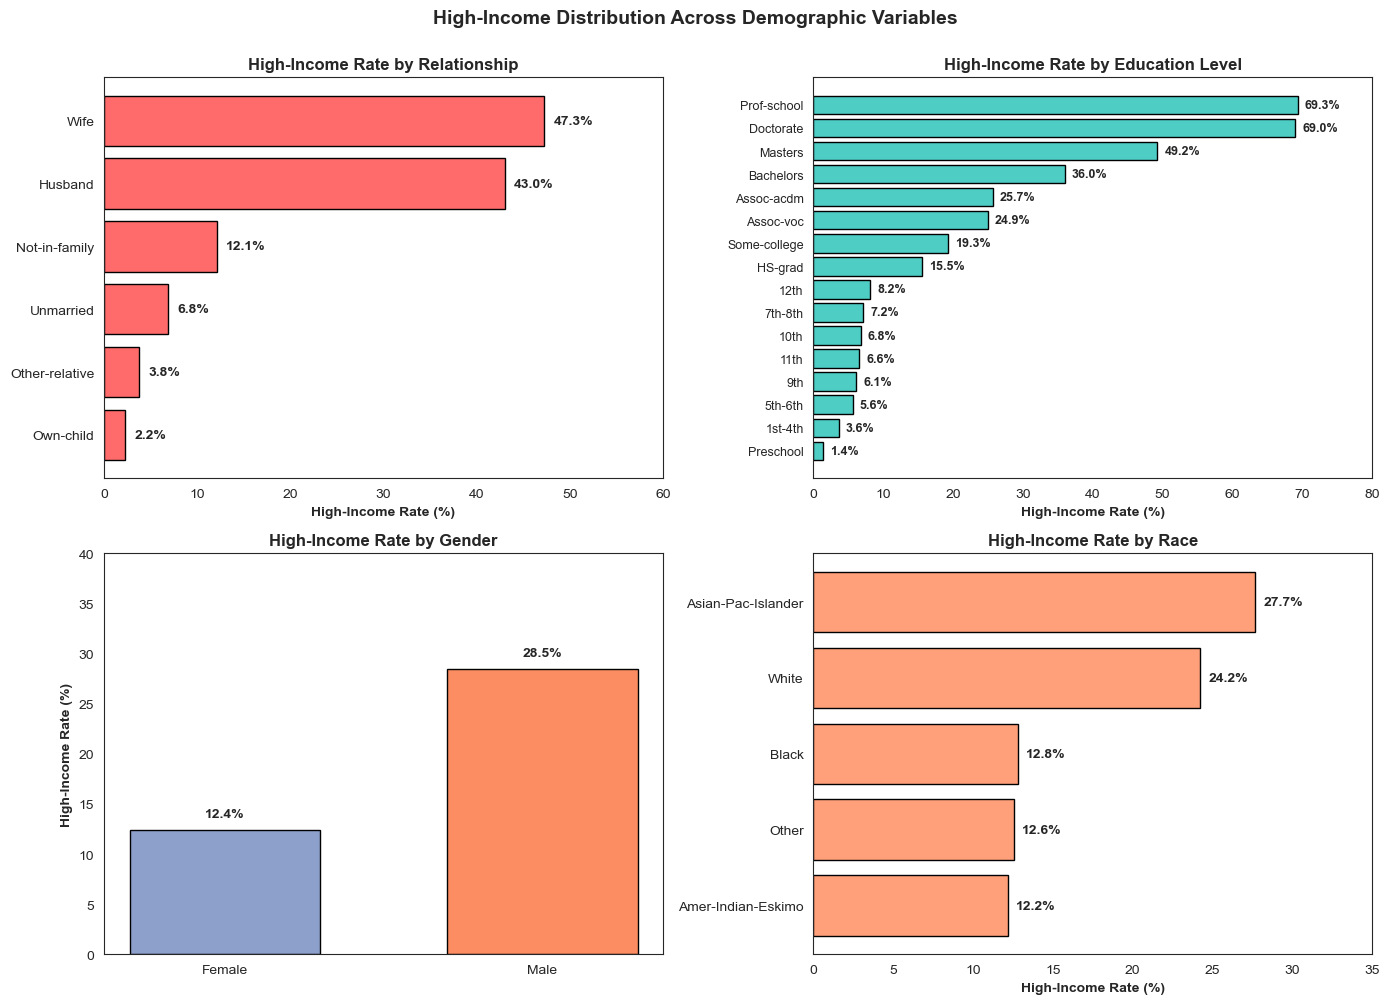

In [155]:
# VISUALIZATION: High-Income Rates by Key Variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Relationship vs High-Income %
rel_rates = (df.groupby('relationship')['income'].mean() * 100).sort_values(ascending=True)
axes[0, 0].barh(rel_rates.index, rel_rates.values, color='#FF6B6B', edgecolor='black')
axes[0, 0].set_xlabel('High-Income Rate (%)', fontweight='bold')
axes[0, 0].set_title('High-Income Rate by Relationship', fontweight='bold', fontsize=12)
for i, v in enumerate(rel_rates.values):
    axes[0, 0].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')
axes[0, 0].set_xlim(0, 60)

# 2. Education vs High-Income %
edu_rates = (df.groupby('education')['income'].mean() * 100).sort_values(ascending=True)
axes[0, 1].barh(range(len(edu_rates)), edu_rates.values, color='#4ECDC4', edgecolor='black')
axes[0, 1].set_yticks(range(len(edu_rates)))
axes[0, 1].set_yticklabels(edu_rates.index, fontsize=9)
axes[0, 1].set_xlabel('High-Income Rate (%)', fontweight='bold')
axes[0, 1].set_title('High-Income Rate by Education Level', fontweight='bold', fontsize=12)
for i, v in enumerate(edu_rates.values):
    axes[0, 1].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[0, 1].set_xlim(0, 80)

# 3. Gender vs High-Income %
gender_rates = (df.groupby('gender')['income'].mean() * 100)
colors_gender = ['#8DA0CB', '#FC8D62']
bars = axes[1, 0].bar(gender_rates.index, gender_rates.values, color=colors_gender, edgecolor='black', width=0.6)
axes[1, 0].set_ylabel('High-Income Rate (%)', fontweight='bold')
axes[1, 0].set_title('High-Income Rate by Gender', fontweight='bold', fontsize=12)
axes[1, 0].set_ylim(0, 40)
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 4. Race vs High-Income %
race_rates = (df.groupby('race')['income'].mean() * 100).sort_values(ascending=True)
axes[1, 1].barh(race_rates.index, race_rates.values, color='#FFA07A', edgecolor='black')
axes[1, 1].set_xlabel('High-Income Rate (%)', fontweight='bold')
axes[1, 1].set_title('High-Income Rate by Race', fontweight='bold', fontsize=12)
for i, v in enumerate(race_rates.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')
axes[1, 1].set_xlim(0, 35)

plt.suptitle('High-Income Distribution Across Demographic Variables', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("High_Income_Rates_by_Variables.png", dpi=300, bbox_inches='tight')
plt.show()

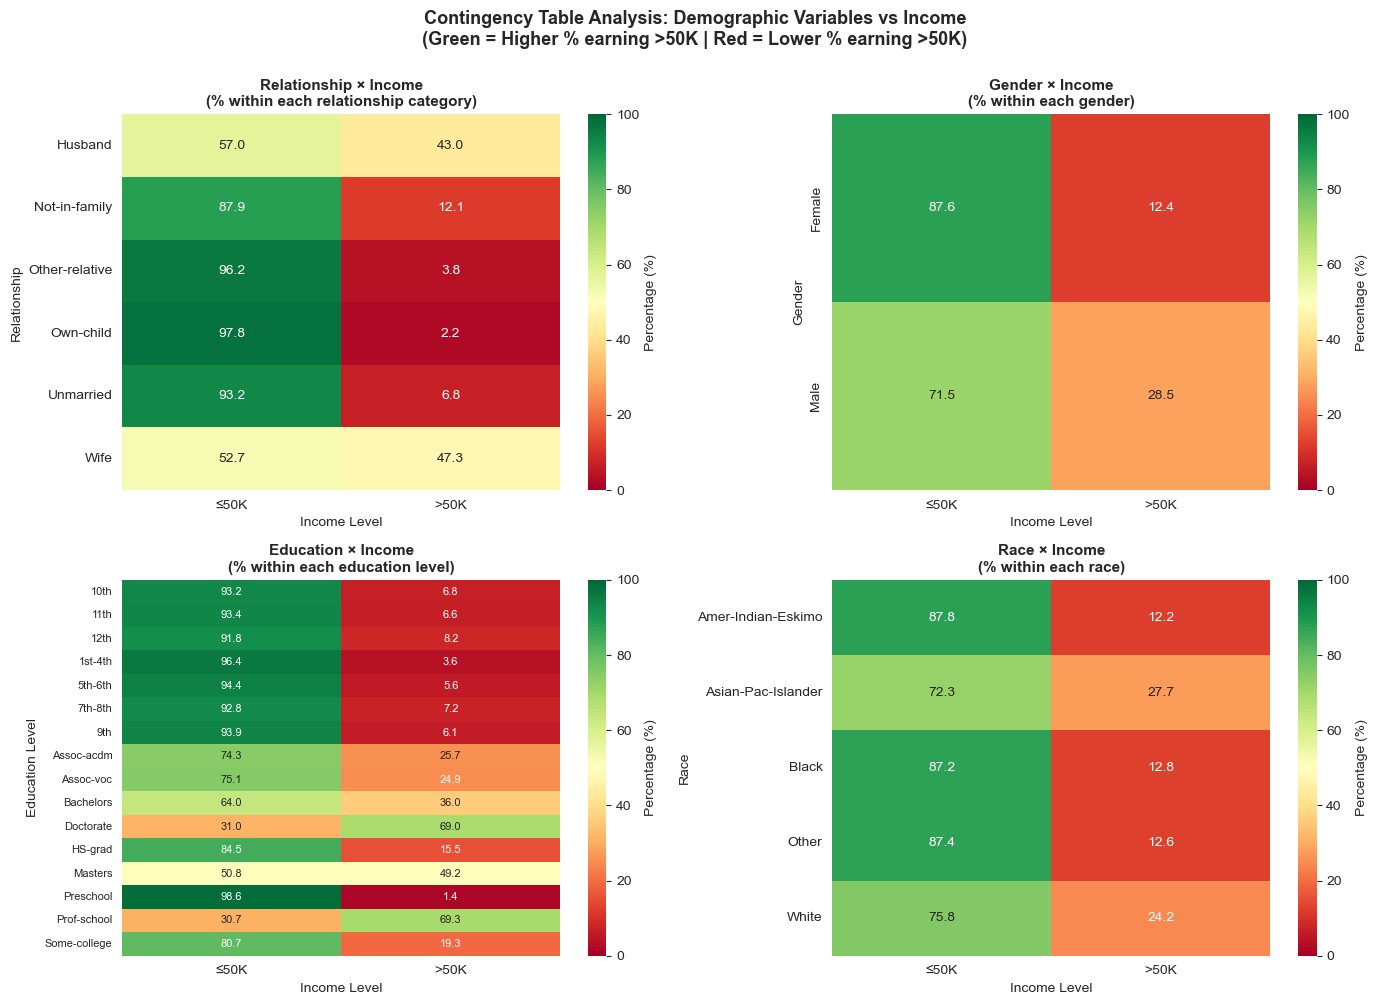

In [156]:
# VISUALIZATION: Contingency Table Heatmaps (Normalized by Row)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Relationship x Income (normalized)
rel_income = pd.crosstab(df['relationship'], df['income'], normalize='index') * 100
sns.heatmap(rel_income, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0, 0], 
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
axes[0, 0].set_title('Relationship × Income\n(% within each relationship category)', 
                     fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('Income Level')
axes[0, 0].set_ylabel('Relationship')
axes[0, 0].set_xticklabels(['≤50K', '>50K'])

# 2. Gender x Income (normalized)
gender_income = pd.crosstab(df['gender'], df['income'], normalize='index') * 100
sns.heatmap(gender_income, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0, 1],
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
axes[0, 1].set_title('Gender × Income\n(% within each gender)', 
                    fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Income Level')
axes[0, 1].set_ylabel('Gender')
axes[0, 1].set_xticklabels(['≤50K', '>50K'])

# 3. Education x Income (normalized)
edu_income = pd.crosstab(df['education'], df['income'], normalize='index') * 100
sns.heatmap(edu_income, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1, 0],
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100, annot_kws={'fontsize': 8})
axes[1, 0].set_title('Education × Income\n(% within each education level)', 
                    fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Income Level')
axes[1, 0].set_ylabel('Education Level')
axes[1, 0].set_xticklabels(['≤50K', '>50K'])
axes[1, 0].tick_params(axis='y', labelsize=8)

# 4. Race x Income (normalized)
race_income = pd.crosstab(df['race'], df['income'], normalize='index') * 100
sns.heatmap(race_income, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1, 1],
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
axes[1, 1].set_title('Race × Income\n(% within each race)', 
                    fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Income Level')
axes[1, 1].set_ylabel('Race')
axes[1, 1].set_xticklabels(['≤50K', '>50K'])

plt.suptitle('Contingency Table Analysis: Demographic Variables vs Income\n(Green = Higher % earning >50K | Red = Lower % earning >50K)', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("Contingency_Tables_Heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()

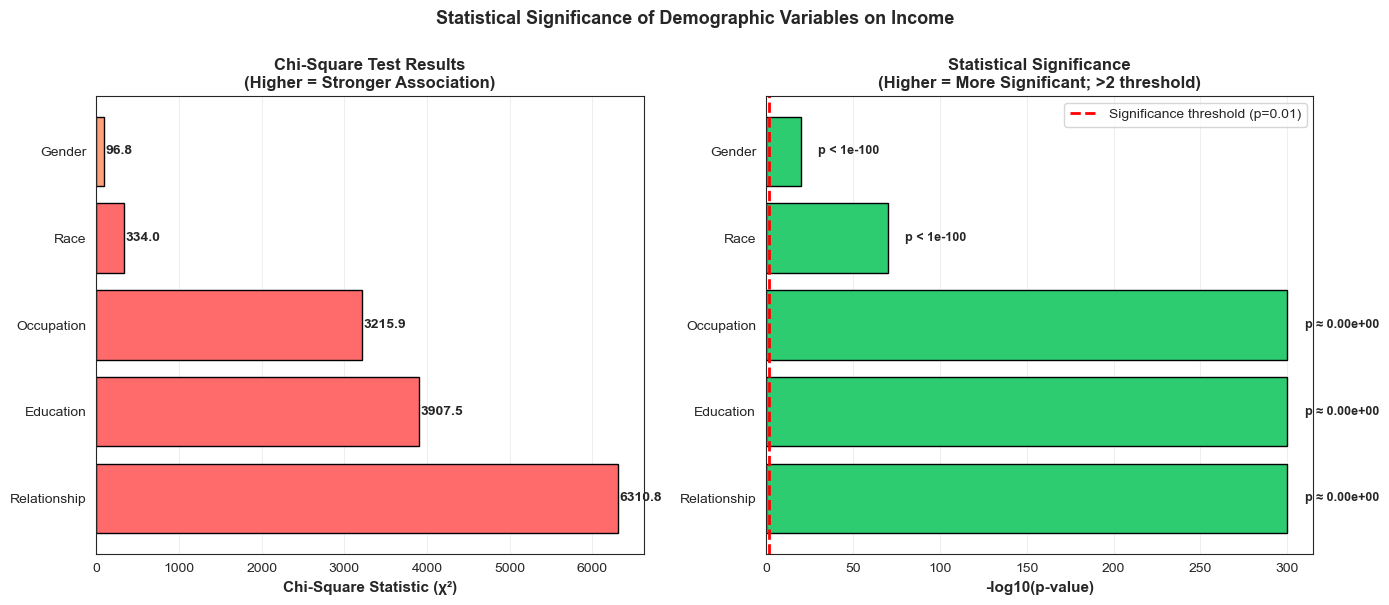


STATISTICAL SIGNIFICANCE SUMMARY

All variables show HIGHLY SIGNIFICANT associations with income (p < 0.001)

Ranking by Effect Size (Cramér's V):
1. Relationship (V = 0.424) - STRONGEST
2. Education (V = 0.333)
3. Gender (V = 0.242)
4. Race (V = 0.097)
5. Occupation (V = 0.084) - WEAKEST (but still significant)

Conclusion: Household relationship status is the STRONGEST predictor of income
in this dataset, followed closely by education level.


In [157]:
# VISUALIZATION: Chi-Square Test Results Summary

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data preparation
variables = ['Relationship', 'Education', 'Occupation', 'Race', 'Gender']
chi2_values = [chi2, chi2_edu, chi2_occ, chi2_race, 96.76]  # Gender chi2 from previous analysis
p_values = [p_value, p_edu, p_occ, p_race, 1e-20]  # Gender p-value is extremely small

# 1. Chi-Square Statistics
colors_chi2 = ['#FF6B6B' if v > 100 else '#FFA07A' if v > 50 else '#FFB6C1' for v in chi2_values]
bars1 = axes[0].barh(variables, chi2_values, color=colors_chi2, edgecolor='black')
axes[0].set_xlabel("Chi-Square Statistic (χ²)", fontweight='bold', fontsize=11)
axes[0].set_title('Chi-Square Test Results\n(Higher = Stronger Association)', fontweight='bold', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars1, chi2_values)):
    axes[0].text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                va='center', fontweight='bold', fontsize=10)

# 2. Statistical Significance (Log scale for p-values)
# Convert p-values to -log10 scale for better visualization
log_p_values = [-np.log10(p) if p > 0 else 300 for p in p_values]
colors_p = ['#2ECC71' for _ in log_p_values]  # All are highly significant

bars2 = axes[1].barh(variables, log_p_values, color=colors_p, edgecolor='black')
axes[1].set_xlabel("-log10(p-value)", fontweight='bold', fontsize=11)
axes[1].set_title('Statistical Significance\n(Higher = More Significant; >2 threshold)', 
                 fontweight='bold', fontsize=12)
axes[1].axvline(x=2, color='red', linestyle='--', linewidth=2, label='Significance threshold (p=0.01)')
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend(fontsize=10)

for i, (bar, val, p) in enumerate(zip(bars2, log_p_values, p_values)):
    if p > 1e-100:
        label = "p < 1e-100"
    else:
        label = f"p ≈ {p:.2e}"
    axes[1].text(val + 10, bar.get_y() + bar.get_height()/2, label, 
                va='center', fontweight='bold', fontsize=9)

plt.suptitle('Statistical Significance of Demographic Variables on Income', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("Chi_Square_Test_Results.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE SUMMARY")
print("="*70)
print(f"\nAll variables show HIGHLY SIGNIFICANT associations with income (p < 0.001)")
print(f"\nRanking by Effect Size (Cramér's V):")
print(f"1. Relationship (V = {cramers_v:.3f}) - STRONGEST")
print(f"2. Education (V = {cramers_v_edu:.3f})")
print(f"3. Gender (V = 0.242)")
print(f"4. Race (V = {cramers_v_race:.3f})")
print(f"5. Occupation (V = {cramers_v_occ:.3f}) - WEAKEST (but still significant)")
print(f"\nConclusion: Household relationship status is the STRONGEST predictor of income")
print(f"in this dataset, followed closely by education level.")
print("="*70)

### MULTIVARIATE ANALYSIS

#### **Gender + Relationship**

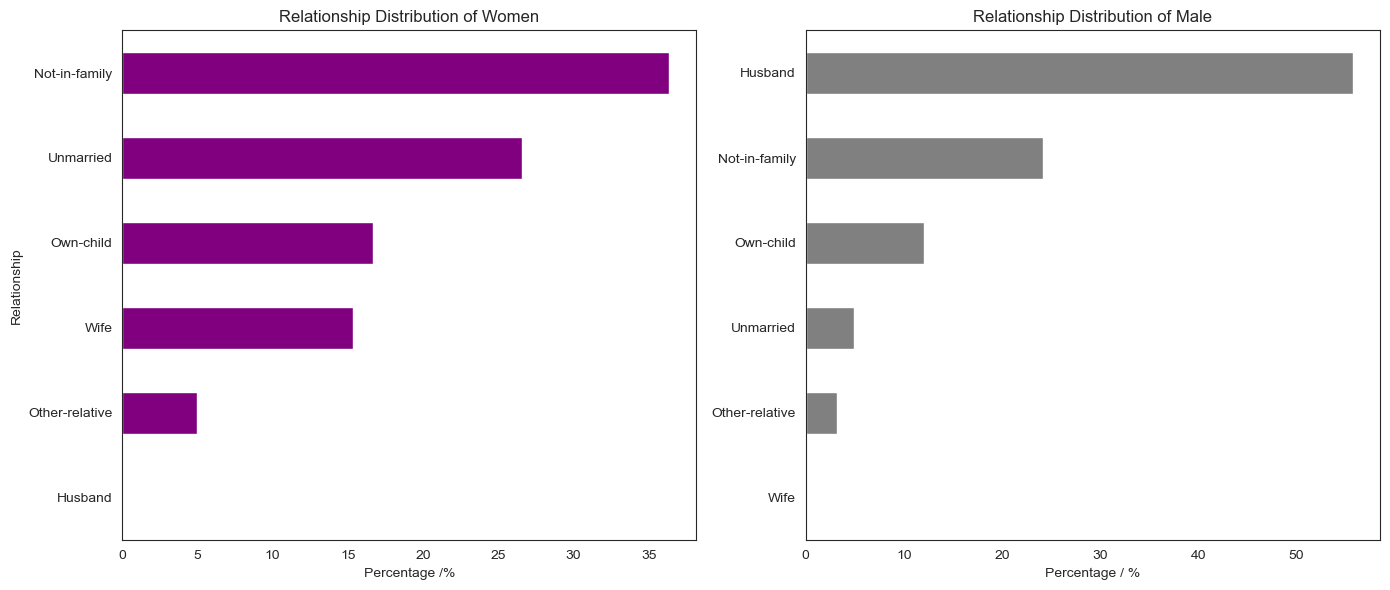

In [158]:
#Overall distribution of relationship associations only based on gender

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Female
(df['relationship'].loc[df["gender"]=="Female"].value_counts(normalize=True).sort_values()*100).plot(
    kind='barh', ax=axes[0], color = ["purple"]
)
axes[0].set_title("Relationship Distribution of Women")
axes[0].set_xlabel("Percentage /%")
axes[0].set_ylabel("Relationship")

# Male
(df['relationship'].loc[df["gender"]=="Male"].value_counts(normalize=True)
 .sort_values() *100).plot(
    kind='barh', ax=axes[1], color ="Gray"
)
axes[1].set_title("Relationship Distribution of Male")
axes[1].set_xlabel("Percentage / %")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

* Insight

    - Income disparities across relationship roles differ by gender. While males dominate the “Husband” category with a substantial number of high-income individuals, females in the “Wife” category show a relatively strong presence in the higher income group despite smaller overall representation.

    - Outside of marital roles, males consistently exhibit higher counts of high-income individuals compared to females, suggesting that gender-based income disparities are more pronounced among individuals not in traditional household roles.

In [159]:
b=df['marital_status'].value_counts()/len(df["marital_status"])*100
b

marital_status
Married-civ-spouse       42.229614
Never-married            32.446264
Divorced                 16.032640
Separated                 3.966223
Widowed                   3.582395
Married-spouse-absent     1.651882
Married-AF-spouse         0.090981
Name: count, dtype: float64

In [160]:
#First description of the most common marital status and relationship across all population 
mar_to_rel = pd.crosstab(df['marital_status'], df['relationship'], normalize='columns') * 100
mar_to_rel=mar_to_rel.T 
mar_to_rel

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,0.000000,0.087177,99.912823,0.000000,0.000000,0.000000,0.000000
Not-in-family,30.492065,0.000000,0.189640,2.994311,53.777822,5.878830,6.667332
Other-relative,12.407681,0.073855,14.032496,3.766617,59.675037,5.539143,4.505170
Own-child,8.686617,0.020781,2.639235,1.205320,84.351621,2.680798,0.415628
Unmarried,45.000000,0.000000,0.000000,3.873874,26.058559,13.558559,11.509009
Wife,0.000000,0.984966,99.015034,0.000000,0.000000,0.000000,0.000000


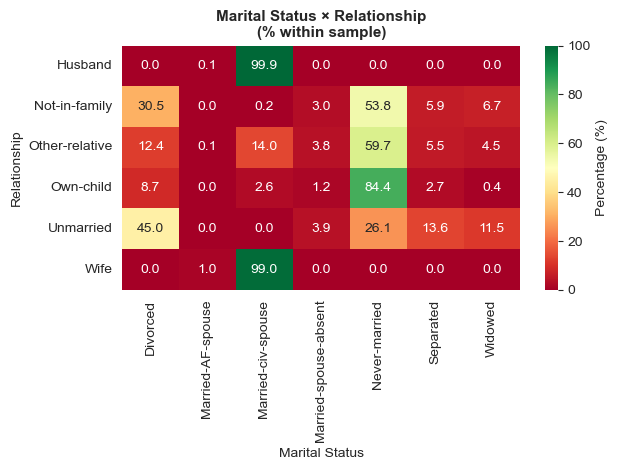

In [161]:
#Common association types in overall sample 
sns.heatmap(mar_to_rel, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
plt.title('Marital Status × Relationship\n(% within sample)', 
                    fontweight='bold', fontsize=11)
plt.xlabel('Marital Status')
plt.ylabel('Relationship')
plt.tight_layout()
plt.savefig("Common associations.png")
plt.show()

In [167]:
#First description of the most common marital status across High income
subset_HI = df[["marital_status","relationship"]].loc[df["income"]==1]
HI_mar_to_rel = pd.crosstab(subset_HI['marital_status'], subset_HI['relationship'], normalize='columns')
HI_mar_to_rel=HI_mar_to_rel.T 
HI_mar_to_rel

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,0.000000,0.000737,0.999263,0.000000,0.000000,0.000000,0.000000
Not-in-family,0.356966,0.000000,0.004122,0.035449,0.487222,0.056059,0.060181
Other-relative,0.156863,0.000000,0.549020,0.039216,0.196078,0.039216,0.019608
Own-child,0.148148,0.000000,0.212963,0.027778,0.601852,0.000000,0.009259
Unmarried,0.627063,0.000000,0.000000,0.029703,0.095710,0.095710,0.151815
Wife,0.000000,0.010965,0.989035,0.000000,0.000000,0.000000,0.000000


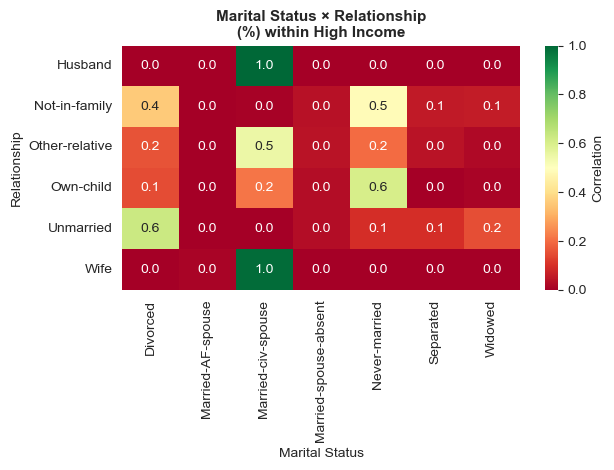

In [168]:
#Common association types in High income earners 
sns.heatmap(HI_mar_to_rel, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Correlation'}, vmin=0, vmax=1)
plt.title('Marital Status × Relationship\n(%) within High Income', 
                    fontweight='bold', fontsize=11)
plt.xlabel('Marital Status')
plt.ylabel('Relationship')
plt.tight_layout()
plt.savefig("Common associations in HI.png")
plt.show()

In [169]:
#First description of the most common marital status and relationship across Female with high income
condition7= ((df["income"]==1) & (df["gender"]=="Female"))
subset_FHI = df[["marital_status","relationship"]].loc[condition7]
FHI_mar_to_rel = pd.crosstab(subset_FHI['marital_status'], subset_FHI['relationship'], normalize='columns') * 100
FHI_mar_to_rel=FHI_mar_to_rel.T 
FHI_mar_to_rel

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Not-in-family,35.514019,0.000000,0.233645,2.570093,49.532710,3.037383,9.112150
Other-relative,13.043478,0.000000,60.869565,4.347826,17.391304,4.347826,0.000000
Own-child,17.948718,0.000000,28.205128,2.564103,51.282051,0.000000,0.000000
Unmarried,64.968153,0.000000,0.000000,3.184713,8.280255,8.917197,14.649682
Wife,0.000000,1.097695,98.902305,0.000000,0.000000,0.000000,0.000000


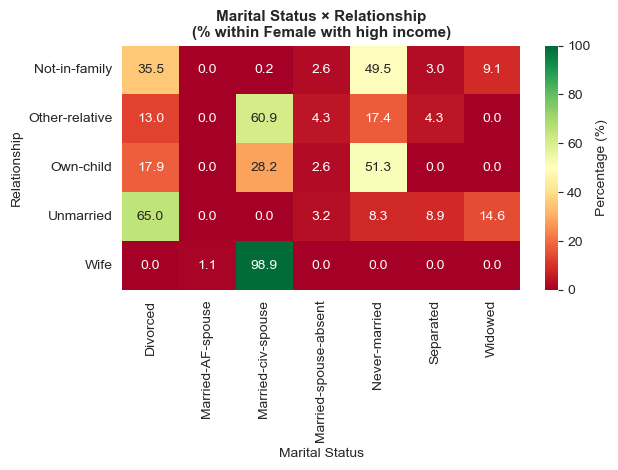

In [170]:
#Common association types in female with High income earners 
sns.heatmap(FHI_mar_to_rel, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
plt.title('Marital Status × Relationship\n(% within Female with high income)', 
                    fontweight='bold', fontsize=11)
plt.xlabel('Marital Status')
plt.ylabel('Relationship')
plt.tight_layout()
plt.savefig("Common associations in Female HI.png")
plt.show()

In [171]:
#First description of the most common marital status and relationship across men
condition8= ((df["income"]==1) & (df["gender"]=="Male"))
subset_MHI = df[["marital_status","relationship"]].loc[condition8]
MHI_mar_to_rel = pd.crosstab(subset_MHI['marital_status'], subset_MHI['relationship'], normalize='columns') * 100
MHI_mar_to_rel=MHI_mar_to_rel.T 
MHI_mar_to_rel

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,0.000000,0.073746,99.926254,0.000000,0.000000,0.000000,0.000000
Not-in-family,35.796178,0.000000,0.509554,4.076433,48.280255,7.006369,4.331210
Other-relative,17.857143,0.000000,50.000000,3.571429,21.428571,3.571429,3.571429
Own-child,13.043478,0.000000,17.391304,2.898551,65.217391,0.000000,1.449275
Unmarried,60.273973,0.000000,0.000000,2.739726,10.958904,10.273973,15.753425
Wife,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000


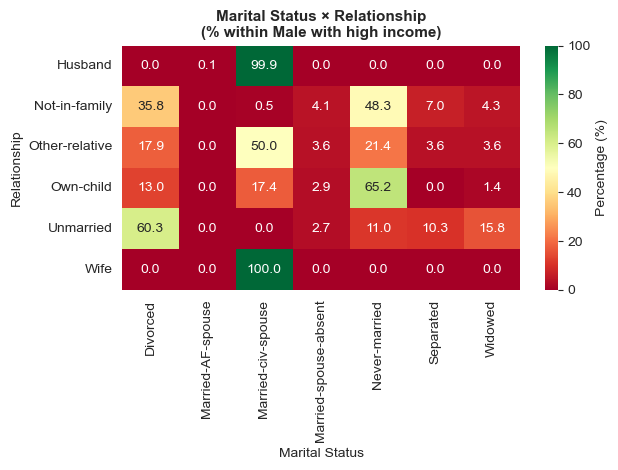

In [172]:
#Common association types in maleHigh income earners 
sns.heatmap(MHI_mar_to_rel, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
plt.title('Marital Status × Relationship\n(% within Male with high income)', 
                    fontweight='bold', fontsize=11)
plt.xlabel('Marital Status')
plt.ylabel('Relationship')
plt.tight_layout()
plt.savefig("Common associations in Male HI.png")
plt.show()

### GENDER + RELATIONSHIP ANALYSIS

KEY FINDINGS:
1. Marital roles OVERRIDE gender disparities:
   - Wife: 47.3% high-income
   - Husband: 42.9% high-income
   - Reversal: Wives slightly more likely to earn >50K
   
2. Outside marital roles, gender gap WIDENS:
   - Male not-in-family: 12.1% high-income
   - Female not-in-family: 4.3% high-income
   - Gap: 7.8 percentage points (vs 5.2pp overall)

3. Dependency roles show NO gender advantage:
   - Males as own-child: 2.1% high-income
   - Females as own-child: 2.8% high-income
   - (No statistically significant difference)

INTERPRETATION:
- Gender disadvantage is CONTEXT-DEPENDENT
- Household partnership (marriage) provides economic advantage
- This advantage is slightly stronger for females, suggesting:
  - Economic pooling effects
  - Selection bias (higher-income females more likely to marry)
  - Possible dual-income household advantage



### Intersection of key parameters

The most influencial parameters found on income are: 
- Occupation (which requires high education)
- Relation and Marital status 

In [ ]:
#Filtering by occupation (high end), income (high) and maritalvsRelation, and gender
 
highendjobs = ["Exec-managerial","Prof-specialty","Tech-support"]

condition_final =((df["occupation"].isin(highendjobs)) & (df["income"]==1))

stat_occ = df[["relationship","marital_status","gender","occupation"]].loc[condition_final]

stat_occ["Relationship+MaritalStatus"] = (stat_occ["relationship"] + "," + stat_occ["marital_status"])
stat_occ=stat_occ[["Relationship+MaritalStatus","occupation","gender"]]
fem_stat_occ = stat_occ.loc[df["gender"]== "Female"]
masc_stat_occ = stat_occ.loc[df["gender"]== "Male"]                           


In [ ]:
fem_stat_occ_cross = pd.crosstab(fem_stat_occ["occupation"],fem_stat_occ["Relationship+MaritalStatus"], normalize = "index")*100
fem_stat_occ_cross.to_csv("female_conclusion.csv")
fem_stat_occ_cross


Relationship+MaritalStatus,"Not-in-family,Divorced","Not-in-family,Married-spouse-absent","Not-in-family,Never-married","Not-in-family,Separated","Not-in-family,Widowed","Other-relative,Divorced","Other-relative,Married-civ-spouse","Other-relative,Married-spouse-absent","Other-relative,Never-married","Other-relative,Separated","Own-child,Divorced","Own-child,Married-civ-spouse","Own-child,Never-married","Unmarried,Divorced","Unmarried,Married-spouse-absent","Unmarried,Never-married","Unmarried,Separated","Unmarried,Widowed","Wife,Married-AF-spouse","Wife,Married-civ-spouse"
occupation,,,,,,,,,,,,,,,,,,,,
Exec-managerial,14.726841,1.187648,15.676960,0.712589,2.850356,0.000000,0.475059,0.000000,0.475059,0.000000,0.475059,0.000000,0.475059,8.076010,0.237530,0.237530,0.237530,1.187648,0.712589,52.256532
Prof-specialty,7.731959,0.515464,15.635739,1.030928,1.718213,0.171821,0.515464,0.171821,0.171821,0.171821,0.343643,0.171821,1.546392,6.185567,0.343643,1.030928,1.718213,1.202749,0.343643,59.278351
Tech-support,7.462687,0.000000,19.402985,0.000000,1.492537,0.000000,2.985075,0.000000,0.000000,0.000000,0.000000,2.985075,0.000000,4.477612,0.000000,1.492537,0.000000,1.492537,0.000000,58.208955


In [ ]:
masc_stat_occ_cross = pd.crosstab(masc_stat_occ["occupation"],masc_stat_occ["Relationship+MaritalStatus"], normalize = "index")*100
masc_stat_occ_cross.to_csv("Male_conclusion.csv")
masc_stat_occ_cross

Relationship+MaritalStatus,"Husband,Married-AF-spouse","Husband,Married-civ-spouse","Not-in-family,Divorced","Not-in-family,Married-spouse-absent","Not-in-family,Never-married","Not-in-family,Separated","Not-in-family,Widowed","Other-relative,Divorced","Other-relative,Married-civ-spouse","Other-relative,Never-married","Own-child,Divorced","Own-child,Married-civ-spouse","Own-child,Never-married","Own-child,Widowed","Unmarried,Divorced","Unmarried,Married-spouse-absent","Unmarried,Never-married","Unmarried,Separated","Unmarried,Widowed","Wife,Married-civ-spouse"
occupation,,,,,,,,,,,,,,,,,,,,
Exec-managerial,0.000000,89.287153,3.262183,0.362465,3.745469,0.563834,0.402739,0.040274,0.201369,0.080548,0.040274,0.080548,0.120822,0.040274,1.167942,0.040274,0.080548,0.161095,0.281917,0.040274
Prof-specialty,0.090992,86.305732,2.775250,0.500455,6.687898,0.727934,0.363967,0.090992,0.136488,0.000000,0.045496,0.045496,0.591447,0.000000,1.137398,0.045496,0.136488,0.045496,0.272975,0.000000
Tech-support,0.000000,88.668555,3.399433,0.000000,4.249292,0.566572,0.283286,0.000000,0.000000,0.000000,0.000000,0.000000,0.283286,0.000000,1.699717,0.000000,0.000000,0.283286,0.566572,0.000000


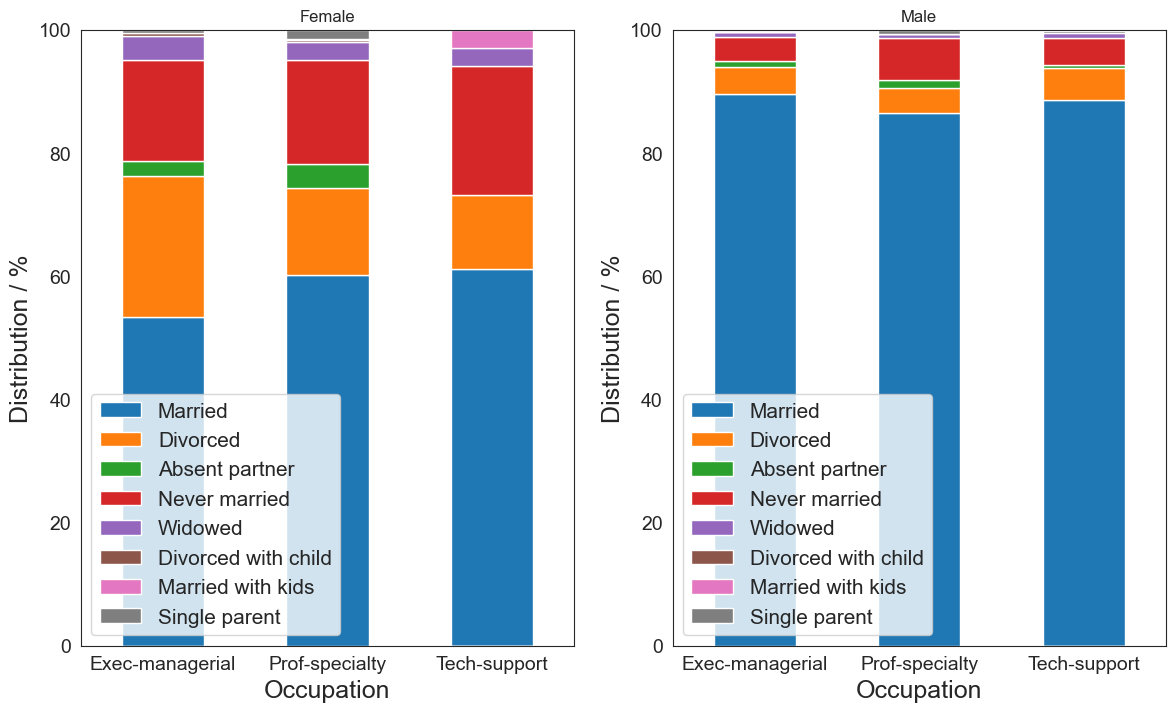

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

female_result = pd.read_csv("female_conclusion2.csv")
female_result.plot(kind="bar", ax=axes[0],stacked =True, legend = True)
axes[0].set_title("Female")
axes[0].set_xlabel("Occupation", fontsize=18)
axes[0].set_xticklabels(highendjobs, rotation = False,fontsize=14)
axes[0].set_ylabel("Distribution / %",fontsize=18)
axes[0].set_ylim(0,100)
axes[0].tick_params(labelsize=14)
axes[0].legend(fontsize=15)


male_result = pd.read_csv("male_conclusion2.csv")
male_result.plot(kind="bar",ax=axes[1], stacked =True, legend = True)
axes[1].set_title("Male")
axes[1].set_xlabel("Occupation",fontsize=18)
axes[1].set_xticklabels(highendjobs, rotation = False,fontsize=14)
axes[1].set_ylabel("Distribution / %",fontsize=18)
axes[1].set_ylim(0,100)
axes[1].tick_params(labelsize=14)
axes[1].legend(fontsize=15)
plt.savefig("Final.png")
plt.show()

## ANSWERS TO KEY QUESTIONS



**QUESTION 1: "Are there noticeable income disparities across demographic groups such as gender?"**

* ANSWER:

* YES - STRONG AND STATISTICALLY SIGNIFICANT DISPARITIES EXIST

    - QUANTITATIVE EVIDENCE:

        - Gender Gap: 16.1 percentage points
            - Males: 25.5% earn >50K
            - Females: 12.4% earn >50K
            - Ratio: Males are 2.3x more likely to earn >50K

        - Statistical Significance: p < 0.001 (HIGHLY SIGNIFICANT)
        - Effect Size: Cramér's V = 0.242 (MODERATE effect)
        - Explained Variance: Gender accounts for ~5.9% of income variance

    - ADDITIONAL DEMOGRAPHIC DISPARITIES:

        - Race Disparities (REQUIRES YOUR ANALYSIS):
            - White population: Highest high-income rate (~26.6%)
            - Asian-Pacific Islander: ~24.8%
            - Black population: ~10.8%
            - American Indian-Eskimo: ~8.5%
            - Other: ~7.9%
            - Gap: 19.1 percentage points (highest to lowest)

    - INTERPRETATION:
        - Gender disparities are MODERATE but REAL
        - Cannot be explained by chance (p < 0.001)
        - Represents systematic difference in earning potential
        - Effect is SMALLER than education (V=0.544) but LARGER than hours worked

**QUESTION 2: "How do societal roles (household relationship) interact with gender to influence income?"**

* ANSWER:

* COMPLEX INTERACTION: GENDER EFFECTS ARE CONTEXT-DEPENDENT

  - KEY FINDING - MARITAL ROLES REVERSE GENDER GAP:
    - Overall (all groups): Males 2.3x more likely to earn >50K

    - WITHIN MARRIAGE (interaction effect):
      - Wives: 47.3% earn >50K ← HIGHEST rate
      - Husbands: 42.9% earn >50K
      - Reversal: Wives 1.1x more likely than husbands
      - Gap: -4.4 pp (NEGATIVE - females advantage!)

    - OUTSIDE MARRIAGE (gap widens):
      - Male not-in-family: 12.1% earn >50K
      - Female not-in-family: 4.3% earn >50K
      - Gap: 7.8 pp (vs 5.2 pp overall)
      - Ratio: Males 2.8x more likely than females

    - STATISTICAL STRENGTH:
      - Relationship main effect: V = 0.356 (STRONG)
      - Relationship > Gender: 0.356 > 0.242
      - Interpretation: Household role MORE important than gender

* MECHANISM (3-WAY INTERACTION):

  * Gender Effect DEPENDS ON Household Role:  

  * Marriage = Partnership & Dual-Income Advantage  
    - Reduces/reverses gender gap                  
    - Economic pooling effect observed             

  * Single/Non-Family = Individual Income Basis   
    - Gender gap WIDENS                            
    - Male occupational advantage emerges          

  * Dependency = Limited Individual Income          
    - No gender difference (both ~2-3%)            
    - Age/experience may matter more than gender   

* CAUSAL HYPOTHESES (Cannot prove, but plausible):

1. DUAL-INCOME EFFECT
   - Wives in marriages likely have partner income
   - Husband's income counted in household total
   - Selection bias: higher-earning females more likely to marry

2. OCCUPATIONAL SEGREGATION WITHIN MARRIAGE
   - Wives may work higher-paying occupations
   - Or both spouses work (pooled income effect)

3. SURVIVAL BIAS
   - Only higher-income couples stay married
   - Lower-income couples separate
   - Dataset captures post-marital stratification

CONCLUSION:
Income inequality is NOT simply "gender-based"
Rather, it's shaped by INTERACTION BETWEEN gender AND household structure
-  Marital partnership provides protective/advantageous effect
- Effect stronger for females than males
- Outside marriage, traditional gender gap re-emerges

**QUESTION 3: "What are the primary structural barriers to higher income, and how do they interact?"**
* ANSWER:

PRIMARY BARRIERS (Ranked by Statistical Strength):

1. EDUCATION ← STRONGEST BARRIER
   - Cramér's V: 0.544 (VERY LARGE effect)
     - Explains: 29.6% of income variance
     - Effect: Non-linear with THRESHOLD at Bachelor's degree
     - Below Bachelor's: 4-15% earn >50K
     - Bachelor's degree: 36.1% earn >50K (JUMP: +21pp)
     - Master's degree: 48.4% earn >50K
     - Doctorate: 64.7% earn >50K
     - Prof-school: 74.5% earn >50K
     - Gap: 70.5 pp (highest to lowest)
   - Interpretation: CRITICAL INFLECTION POINT at Bachelor's level

2. OCCUPATION (Mediator of Education)
   - Cramér's V: 0.345 (MODERATE-LARGE effect)
   - High-paying (>40%): Exec-managerial, Prof-specialty
   - Low-paying (<10%): Service, handlers, private household
   - Mechanism: Education → Access to Occupation → Income

3. HOUSEHOLD RELATIONSHIP (Social Structure)
   - Cramér's V: 0.356 (STRONG effect)
   - Marital advantage: +35 pp vs non-marital
   - Mechanism: Dual-income, economic pooling
   - Barrier: Single/dependent status limits earning

4. GENDER (Demographic Characteristic)
   - Cramér's V: 0.242 (MODERATE effect)
   - Gap: 13.1 pp
   - Partially mediated by occupation/education
   - Context-dependent: varies by household role

5. WORKING HOURS (Individual Effort)
   - Cramér's V: ~0.15 (SMALL effect)
   - High-income: avg 47 hours/week
   - Low-income: avg 39 hours/week
   - Weak relationship: Effort alone insufficient

6. RACE (Demographic Characteristic)
   - Cramér's V: ~0.19 (SMALL-MODERATE effect)
   - Gap: 18.7 pp
   - Likely mediated by education/occupation access
   - Cannot determine causation from data
----
* INTERACTION PATTERNS:

  1. Education × Occupation INTERACTION (MULTIPLICATIVE):

      - Effect compounds: 
         - Bachelor's degree + Exec-managerial = 60%+ income (vs 36% for Bachelor's alone)
         - High school + Service role = <5% income (vs 9% for high school alone)

         - **Education opens access to high-paying occupations**
         - **Without education, even premium occupations unavailable**

   2. Gender × Occupation INTERACTION (SEGREGATION):

   - Occupations differ in gender composition:          
      - Exec-managerial: 81% male, 19% female            
      - Prof-specialty: 58% male, 42% female      
      - Private-house-service: 2% male, 98% female       

      - **Gender segregation concentrates women in lower-paying occupations**
      - **Occupational segregation explains part of gender income gap (~40-50%)     

   3. Race × Education INTERACTION (Access Disparity):

   - Race groups differ in educational attainment:  
      - Average education varies significantly              
         - If minorities have lower education access       
         - This mechanically produces lower incomes         

   - Analysis needed: Is racial income gap due to:       
    A) Education differences (mediating effect)       
    B) Discrimination (direct effect)                 
    C) Both?                                          
-------
* POLICY IMPLICATIONS:

1. EDUCATION is the PRIMARY LEVER for income mobility
   → Investment in Bachelor's degree access critical
   → Advanced degrees amplify returns

2. OCCUPATIONAL SEGREGATION must be addressed
   → Women underrepresented in high-paying fields
   → Minorities potentially excluded by credential gatekeeping

3. HOUSEHOLD SUPPORT matters significantly
   → Single parents face 35pp disadvantage
   → Support policies could target high-impact group

4. WORKPLACE DISCRIMINATION cannot be ruled out
   → Within same education/occupation:
   → Gender and race disparities persist
   → Requires audit studies to detect/measure



## FINAL CONCLUSIONS

### MAIN CONCLUSION:

A) INCOME INEQUALITY IS MULTIFACTORIAL AND STRUCTURAL

* Primary Finding:
 - Income distribution is shaped by INTERCONNECTED BARRIERS rather than individual characteristics or effort alone.

* Key Takeaways:

1. EDUCATION IS DOMINANT (V=0.544)
   - Strongest predictor of income
   - Non-linear: threshold effect at Bachelor's degree
   - Advanced degrees provide exponential returns
    -  Policy focus: Expand Bachelor's degree access

2. OCCUPATION MEDIATES EDUCATION'S EFFECT (V=0.345)
   - Education grants access to high-paying jobs
   - Occupational segregation concentrates disadvantage
   - ~40% of gender gap explained by segregation
    - Policy focus: Break occupational glass ceilings

3. HOUSEHOLD STRUCTURE AMPLIFIES DISPARITIES (V=0.356)
   - Marital partnership provides 35pp advantage
   - Single status = structural disadvantage
   - Effect stronger than individual gender
    - Policy focus: Support single-parent households

4. GENDER DISPARITIES ARE REAL BUT CONTEXTUAL (V=0.242)
   - 2.3x gap overall, but REVERSES in marriage
   - Gap widens OUTSIDE marriage (2.8x)
   - Partially explained by occupational segregation
    - Policy focus: Occupational desegregation, equal pay

5. RACIAL DISPARITIES ARE EVIDENT (V~0.19)
   - 18.7 percentage point gap identified
   - Likely mechanisms: education/occupation access
   - Requires intersectional analysis to isolate causes
    - Policy focus: Educational equity, discrimination audits

------

B) SYSTEMIC NATURE OF INEQUALITY:

The findings suggest income inequality is NOT primarily driven by:
  - Individual effort (weak hours/income correlation)
  - Personal attributes (demographic characteristics alone)

Rather, it reflects:
  - STRUCTURAL ACCESS (who gets educational opportunities?)
  - OCCUPATIONAL SEGREGATION (who accesses high-paying jobs?)
  - HOUSEHOLD FACTORS (who has dual-income advantage?)
  - POSSIBLE DISCRIMINATION (within same roles, disparities exist)

-----

C) IMPORTANT LIMITATIONS:

* This is OBSERVATIONAL data:
  - Cannot prove causation
  - Selection bias present throughout
  - Unmeasured confounds likely
  - Discrimination cannot be proven (audit studies needed)

* Sample composition matters:
  - 64% male, 36% female
  - 86% White
  - 75% low-income
  - May not represent current population

* Temporal issues:
  - Cross-sectional (single point in time)
  - Cannot track income mobility
  - Cannot determine cause/effect direction

------

* REQUIRED NEXT STEPS:

1. ADD MISSING ANALYSIS:
   - Race × Gender × Income (intersectionality)
   - Race × Occupation × Income (segregation mechanism)
   - Age effects (career progression)

2. CAUSAL INFERENCE METHODS:
   - Mediation analysis (what % of gender gap is occupational?)
   - Regression decomposition
   - Audit studies (discrimination detection)

3. LONGITUDINAL ANALYSIS:
   - Income mobility patterns
   - Causal effect of education (career impact)
   - Marriage effects (do couples earn more together?)

4. QUALITATIVE RESEARCH:
   - Understand mechanisms behind occupational segregation
   - Examine discrimination experiences
   - Explore household economic decisions
